In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\vinay\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import openpyxl
print(openpyxl.__version__)

3.1.5


In [4]:
df = pd.read_excel("Flight_Fare.xlsx")

In [5]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [6]:
df.shape

(10683, 11)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [9]:
df[df.isnull().any(axis=1)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [10]:
df.duplicated().sum()

np.int64(220)

In [11]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [12]:
df[df.duplicated(keep=False)].sort_values(
    by=["Airline", "Date_of_Journey", "Source", "Destination"]
).head(20)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
6321,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
9848,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
572,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
8168,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
1495,Air India,1/04/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,01:20 02 Apr,15h 20m,2 stops,No info,10408
9913,Air India,1/04/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,01:20 02 Apr,15h 20m,2 stops,No info,10408
3598,Air India,1/05/2019,Kolkata,Banglore,CCU → GAU → DEL → BLR,09:50,08:55 02 May,23h 5m,2 stops,No info,13227
4603,Air India,1/05/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,13:45 02 May,27h 45m,2 stops,No info,15164
5042,Air India,1/05/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,13:45 02 May,27h 45m,2 stops,No info,15164
6377,Air India,1/05/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,13:45 02 May,27h 45m,2 stops,No info,15164


In [13]:
df.drop_duplicates().shape

(10463, 11)

In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(10463, 11)

In [16]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [17]:
df = df.dropna()

In [18]:
df.shape

(10462, 11)

In [19]:
df["Airline"].value_counts()

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

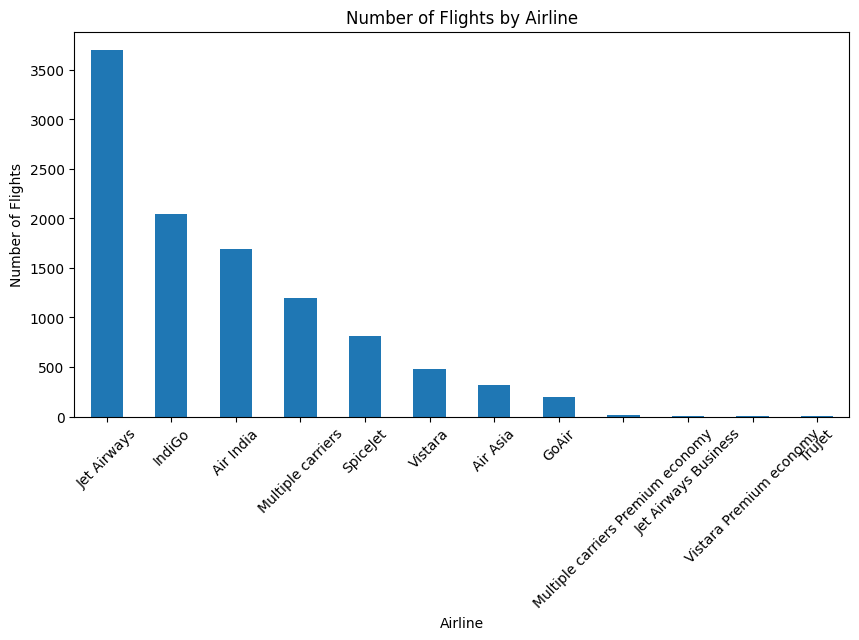

In [20]:
df["Airline"].value_counts().plot(kind="bar", figsize=(10, 5))

plt.title("Number of Flights by Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

In [21]:
df["Source"].value_counts()

Source
Delhi       4345
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64

In [22]:
df["Destination"].value_counts()

Destination
Cochin       4345
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [23]:
df["Route"].value_counts()

Route
DEL → BOM → COK                      2376
BLR → DEL                            1536
CCU → BOM → BLR                       979
CCU → BLR                             724
BOM → HYD                             621
                                     ... 
BOM → VNS → DEL → HYD                   1
BLR → HBX → BOM → NAG → DEL             1
BLR → BOM → IXC → DEL                   1
BLR → CCU → BBI → HYD → VGA → DEL       1
BOM → BBI → HYD                         1
Name: count, Length: 128, dtype: int64

In [24]:
df["Total_Stops"].value_counts()

Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64

In [25]:
df["Additional_Info"].value_counts()

Additional_Info
No info                         8182
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [26]:
df["Date_of_Journey"].value_counts().head(10)

Date_of_Journey
6/06/2019     490
18/05/2019    486
9/06/2019     485
12/06/2019    483
21/05/2019    482
9/05/2019     466
21/03/2019    412
15/05/2019    402
27/05/2019    369
27/06/2019    339
Name: count, dtype: int64

In [27]:
df["Dep_Time"].head(10)

0    22:20
1    05:50
2    09:25
3    18:05
4    16:50
5    09:00
6    18:55
7    08:00
8    08:55
9    11:25
Name: Dep_Time, dtype: str

In [28]:
df["Arrival_Time"].head(10)

0    01:10 22 Mar
1           13:15
2    04:25 10 Jun
3           23:30
4           21:35
5           11:25
6    10:25 13 Mar
7    05:05 02 Mar
8    10:25 13 Mar
9           19:15
Name: Arrival_Time, dtype: str

In [29]:
df["Duration"].head(10)

0     2h 50m
1     7h 25m
2        19h
3     5h 25m
4     4h 45m
5     2h 25m
6    15h 30m
7     21h 5m
8    25h 30m
9     7h 50m
Name: Duration, dtype: str

In [30]:
df["Price"].describe()

count    10462.000000
mean      9026.790289
std       4624.849541
min       1759.000000
25%       5224.000000
50%       8266.000000
75%      12344.750000
max      79512.000000
Name: Price, dtype: float64

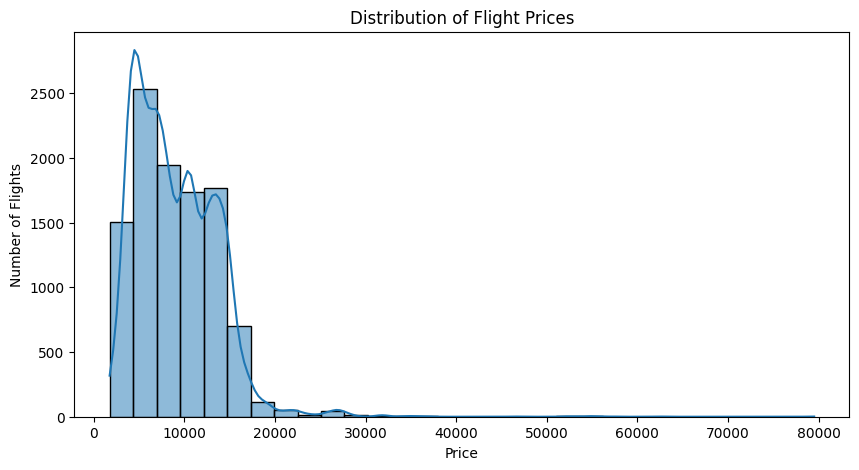

In [31]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Number of Flights")
plt.show()

In [32]:
df.groupby("Airline")["Price"].mean().sort_values(ascending=False)

Airline
Jet Airways Business                 58358.666667
Jet Airways                          11599.021081
Multiple carriers Premium economy    11418.846154
Multiple carriers                    10902.678094
Air India                             9556.608028
Vistara Premium economy               8962.333333
Vistara                               7801.355649
GoAir                                 5861.056701
IndiGo                                5668.469897
Air Asia                              5590.260188
SpiceJet                              4335.841718
Trujet                                4140.000000
Name: Price, dtype: float64

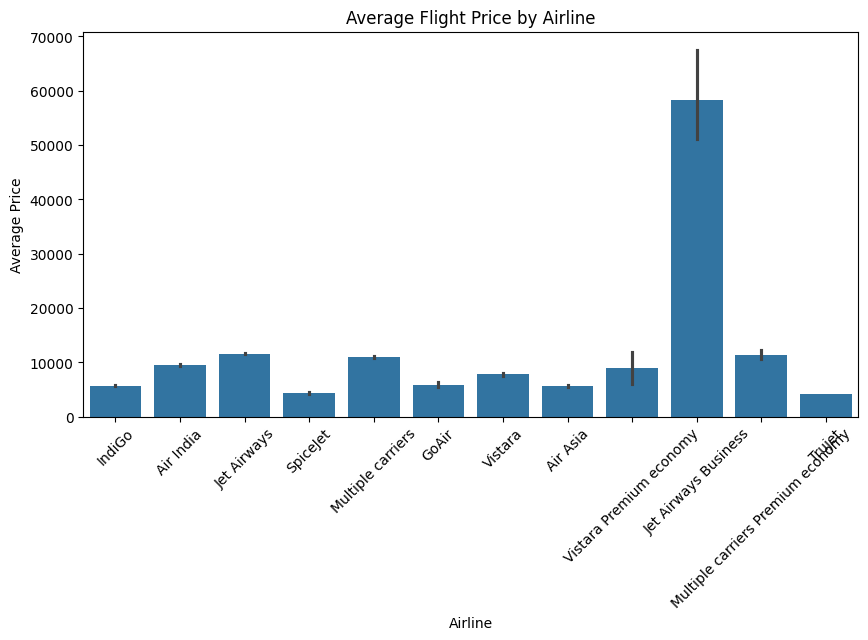

In [33]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Airline",
    y="Price",
    estimator="mean"
)

plt.title("Average Flight Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

In [34]:
df.groupby("Source")["Price"].mean().sort_values(ascending=False)

Source
Delhi       10461.600690
Kolkata      9143.083566
Banglore     8022.872877
Mumbai       5059.708752
Chennai      4789.892388
Name: Price, dtype: float64

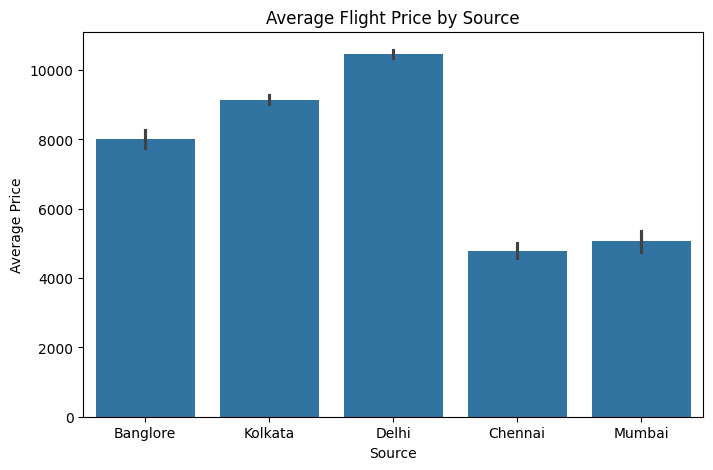

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Source",
    y="Price",
    estimator="mean"
)

plt.title("Average Flight Price by Source")
plt.xlabel("Source")
plt.ylabel("Average Price")
plt.show()

In [36]:
df.groupby("Destination")["Price"].mean().sort_values(ascending=False)

Destination
New Delhi    12007.421225
Cochin       10461.600690
Banglore      9143.083566
Delhi         5143.918577
Hyderabad     5059.708752
Kolkata       4789.892388
Name: Price, dtype: float64

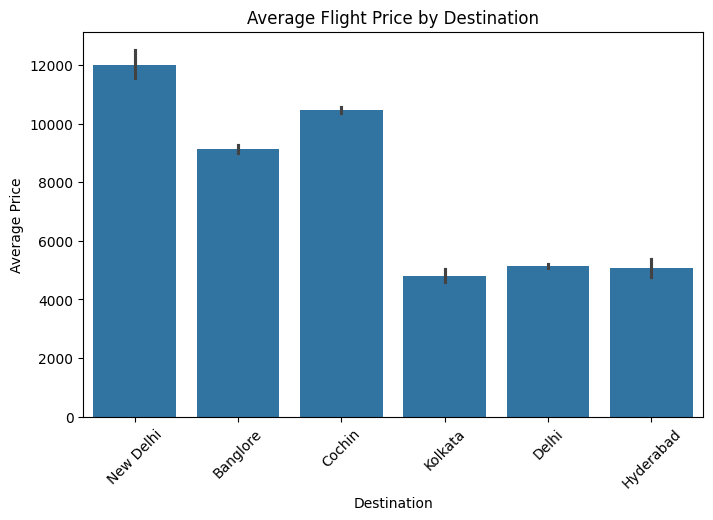

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Destination",
    y="Price",
    estimator="mean"
)

plt.title("Average Flight Price by Destination")
plt.xlabel("Destination")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

In [38]:
df.groupby("Total_Stops")["Price"].mean().sort_values(ascending=False)

Total_Stops
4 stops     17686.000000
3 stops     13260.674419
2 stops     12761.099393
1 stop      10594.123556
non-stop     5018.506763
Name: Price, dtype: float64

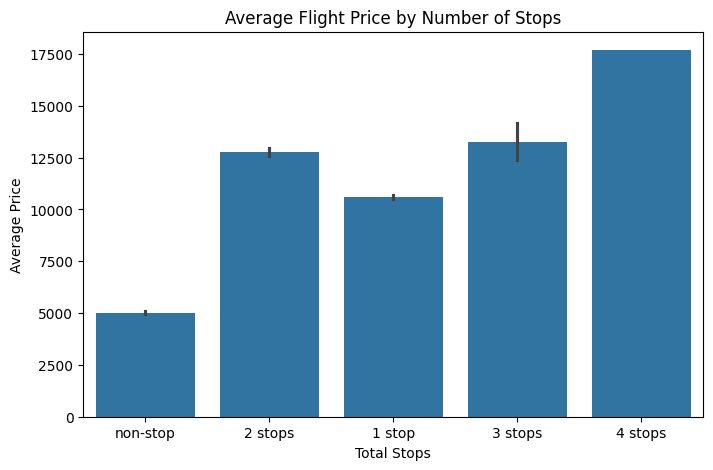

In [39]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Total_Stops",
    y="Price",
    estimator="mean"
)

plt.title("Average Flight Price by Number of Stops")
plt.xlabel("Total Stops")
plt.ylabel("Average Price")
plt.show()

In [40]:
hours = df["Duration"].str.extract(r"(\d+)h")[0].fillna(0).astype(float)
minutes = df["Duration"].str.extract(r"(\d+)m")[0].fillna(0).astype(float)

df["Duration_minutes"] = hours * 60 + minutes

In [41]:
df[["Duration", "Duration_minutes"]].head(10)

,Duration,Duration_minutes
0,2h 50m,170.0
1,7h 25m,445.0
2,19h,1140.0
3,5h 25m,325.0
4,4h 45m,285.0
5,2h 25m,145.0
6,15h 30m,930.0
7,21h 5m,1265.0
8,25h 30m,1530.0
9,7h 50m,470.0


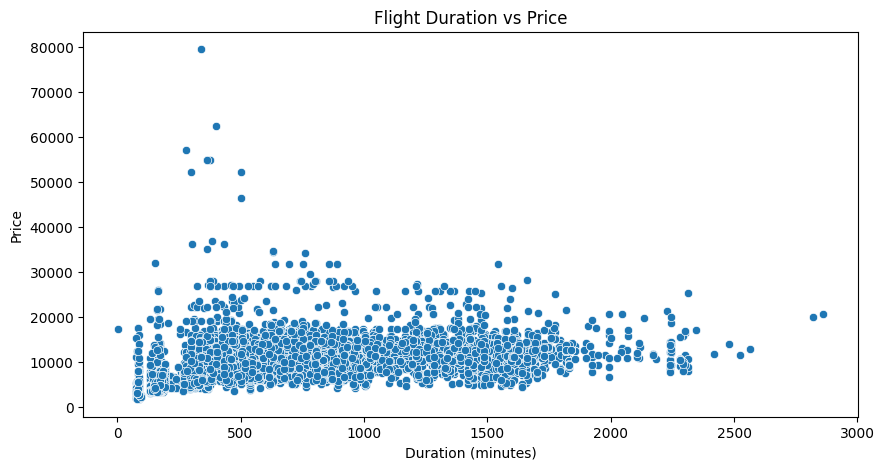

In [42]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="Duration_minutes",
    y="Price"
)

plt.title("Flight Duration vs Price")
plt.xlabel("Duration (minutes)")
plt.ylabel("Price")
plt.show()

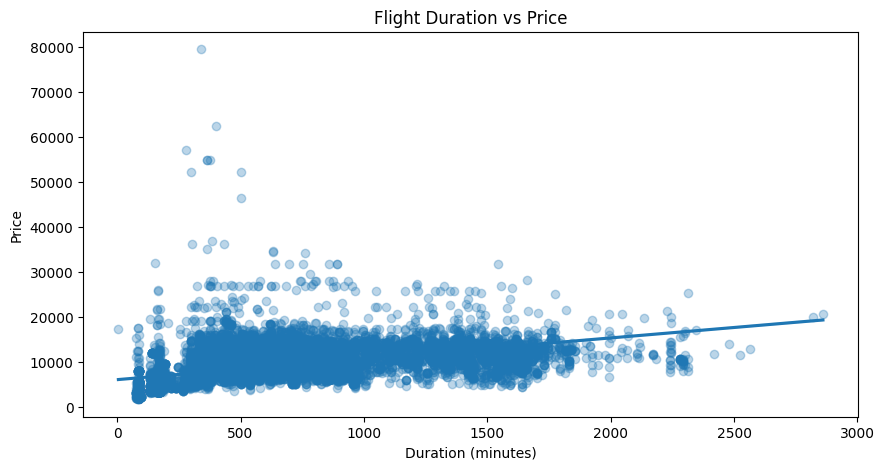

In [43]:
plt.figure(figsize=(10, 5))

sns.regplot(
    data=df,
    x="Duration_minutes",
    y="Price",
    scatter_kws={"alpha": 0.3}
)

plt.title("Flight Duration vs Price")
plt.xlabel("Duration (minutes)")
plt.ylabel("Price")
plt.show()

In [44]:
df["Journey_Month"] = pd.to_datetime(
    df["Date_of_Journey"],
    dayfirst=True
).dt.month

In [45]:
df[["Date_of_Journey", "Journey_Month"]].head(10)

,Date_of_Journey,Journey_Month
0,24/03/2019,3
1,1/05/2019,5
2,9/06/2019,6
3,12/05/2019,5
4,01/03/2019,3
5,24/06/2019,6
6,12/03/2019,3
7,01/03/2019,3
8,12/03/2019,3
9,27/05/2019,5


In [46]:
df.groupby("Journey_Month")["Price"].mean()

Journey_Month
3    10695.397311
4     5766.545455
5     9029.239764
6     8736.152522
Name: Price, dtype: float64

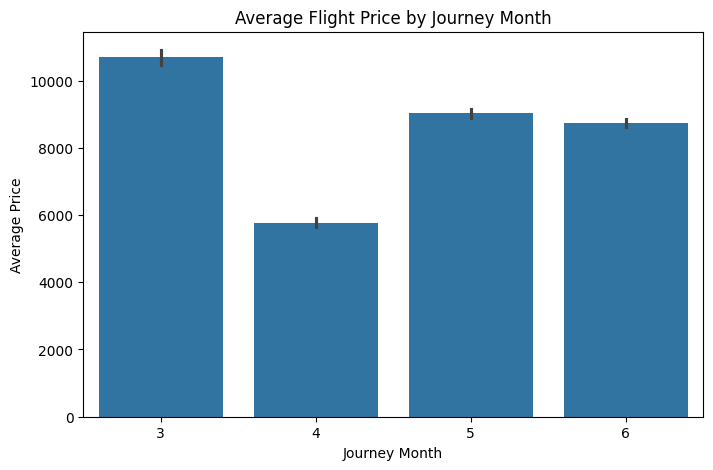

In [47]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Journey_Month",
    y="Price",
    estimator="mean"
)

plt.title("Average Flight Price by Journey Month")
plt.xlabel("Journey Month")
plt.ylabel("Average Price")
plt.show()

In [48]:
df["Dep_Hour"] = pd.to_datetime(
    df["Dep_Time"],
    format="%H:%M"
).dt.hour

In [49]:
df[["Dep_Time", "Dep_Hour"]].head(10)

,Dep_Time,Dep_Hour
0,22:20,22
1,05:50,5
2,09:25,9
3,18:05,18
4,16:50,16
5,09:00,9
6,18:55,18
7,08:00,8
8,08:55,8
9,11:25,11


In [50]:
df.groupby("Dep_Hour")["Price"].mean()

Dep_Hour
0      7615.075000
1      4354.621622
2      8419.974227
3     10474.625000
4      7266.520710
5      9480.309278
6      8252.195556
7      8485.902665
8     10073.923631
9      9559.092551
10     8870.728653
11     9296.739206
12     9251.573034
13     8998.725061
14     9816.409901
15     7687.410658
16    10330.783080
17     8710.355588
18    10043.981859
19     8344.700368
20     9683.838213
21     8450.296524
22     7765.975871
23     8487.338346
Name: Price, dtype: float64

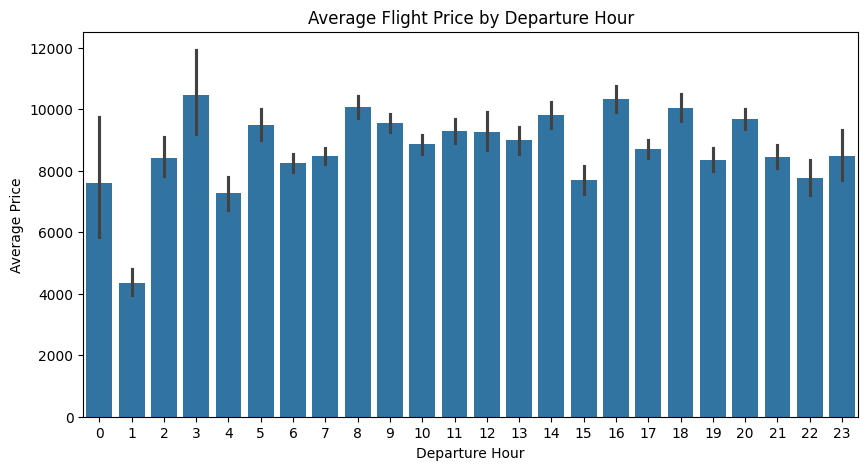

In [51]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Dep_Hour",
    y="Price",
    estimator="mean"
)

plt.title("Average Flight Price by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Average Price")
plt.show()

In [52]:
df["Arrival_Hour"] = pd.to_datetime(
    df["Arrival_Time"].str[:5],
    format="%H:%M"
).dt.hour

In [53]:
df[["Arrival_Time", "Arrival_Hour"]].head(10)

,Arrival_Time,Arrival_Hour
0,01:10 22 Mar,1
1,13:15,13
2,04:25 10 Jun,4
3,23:30,23
4,21:35,21
5,11:25,11
6,10:25 13 Mar,10
7,05:05 02 Mar,5
8,10:25 13 Mar,10
9,19:15,19


In [54]:
df.groupby("Arrival_Hour")["Price"].mean()

Arrival_Hour
0      5642.447205
1      9636.845714
2      5151.886076
3      4934.638298
4     11355.286465
5     15532.151515
6      5819.470588
7      7796.538647
8      8051.175214
9      9203.018405
10     8118.831224
11     7417.629630
12     9560.559814
13     7499.521452
14     6627.581633
15     8925.412088
16     9272.121622
17     5820.633508
18    10612.119843
19    10936.235521
20     8267.570292
21     8676.784593
22     7575.583591
23     8947.058212
Name: Price, dtype: float64

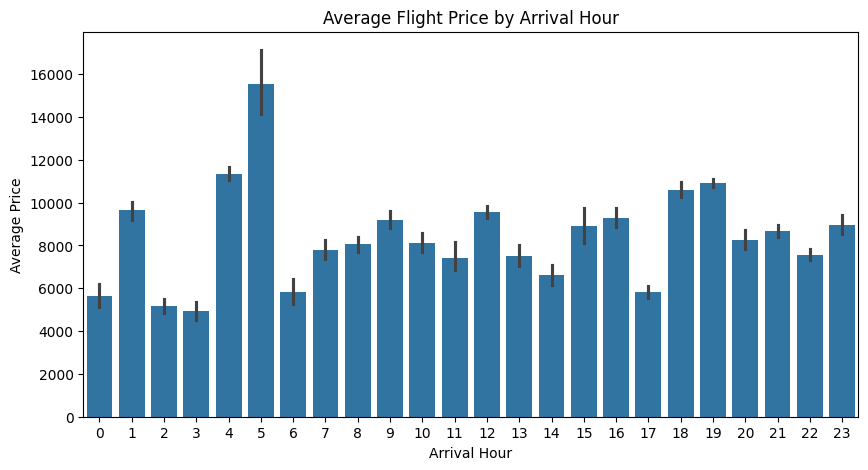

In [55]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Arrival_Hour",
    y="Price",
    estimator="mean"
)

plt.title("Average Flight Price by Arrival Hour")
plt.xlabel("Arrival Hour")
plt.ylabel("Average Price")
plt.show()

In [56]:
df.groupby("Additional_Info")["Price"].mean().sort_values(ascending=False)

Additional_Info
Business class                  56811.250000
1 Short layover                 26743.000000
2 Long layover                  26480.000000
1 Long layover                  22109.631579
Change airports                 16800.714286
Red-eye flight                  10873.000000
In-flight meal not included      9435.647456
No info                          9075.257394
No Info                          8044.666667
No check-in baggage included     3642.465409
Name: Price, dtype: float64

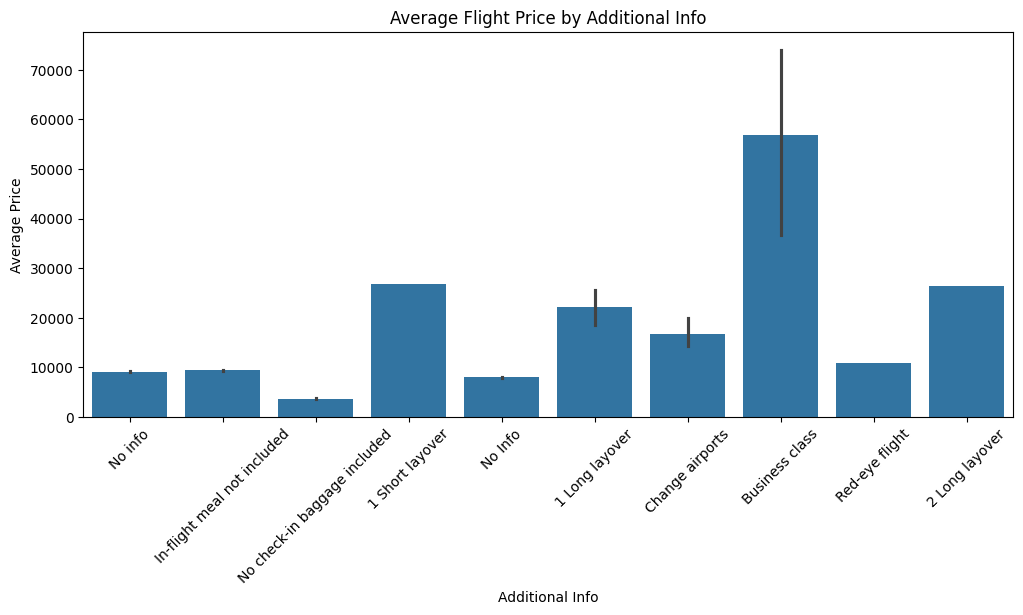

In [57]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=df,
    x="Additional_Info",
    y="Price",
    estimator="mean"
)

plt.title("Average Flight Price by Additional Info")
plt.xlabel("Additional Info")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

In [58]:
df["Route"].value_counts().head(10)

Route
DEL → BOM → COK    2376
BLR → DEL          1536
CCU → BOM → BLR     979
CCU → BLR           724
BOM → HYD           621
CCU → DEL → BLR     565
BLR → BOM → DEL     402
MAA → CCU           381
DEL → HYD → COK     326
DEL → BLR → COK     232
Name: count, dtype: int64

In [59]:
top_routes = df["Route"].value_counts().head(10).index

route_price = (
    df[df["Route"].isin(top_routes)]
    .groupby("Route")["Price"]
    .mean()
    .sort_values(ascending=False)
)

route_price

Route
BLR → BOM → DEL    15723.174129
CCU → BOM → BLR    11487.788560
DEL → BOM → COK    10954.205808
CCU → DEL → BLR    10763.258407
DEL → BLR → COK     7559.612069
DEL → HYD → COK     7299.331288
BLR → DEL           5552.235677
MAA → CCU           4789.892388
CCU → BLR           4556.055249
BOM → HYD           3932.809984
Name: Price, dtype: float64

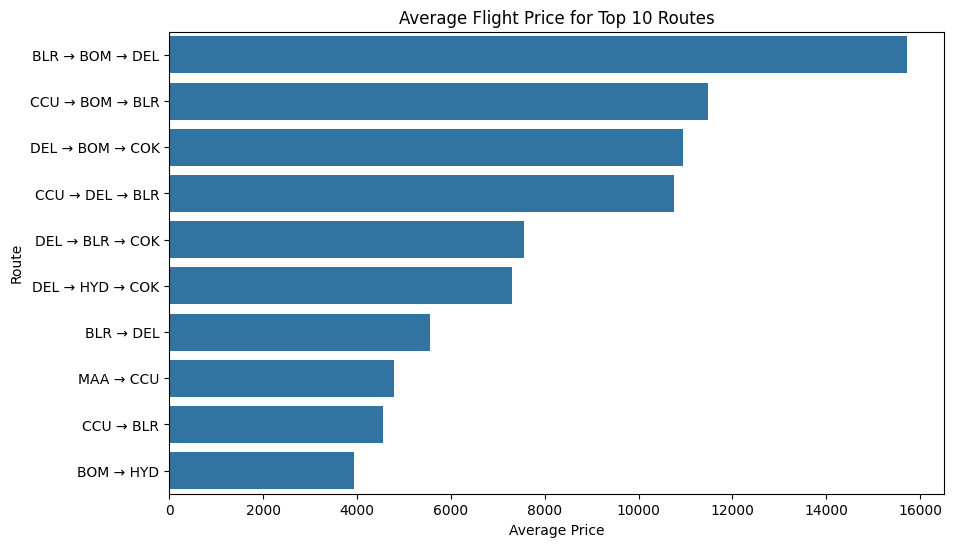

In [60]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=route_price.values,
    y=route_price.index
)

plt.title("Average Flight Price for Top 10 Routes")
plt.xlabel("Average Price")
plt.ylabel("Route")
plt.show()

In [61]:
df["Journey_Day"] = pd.to_datetime(
    df["Date_of_Journey"],
    dayfirst=True
).dt.day

In [62]:
df.groupby("Journey_Day")["Price"].mean()

Journey_Day
1     10457.094518
3      9022.713772
6     10364.533912
9      9474.560000
12     9080.340381
15     8061.858325
18     8561.388206
21     8275.211982
24     8350.679061
27     8061.511905
Name: Price, dtype: float64

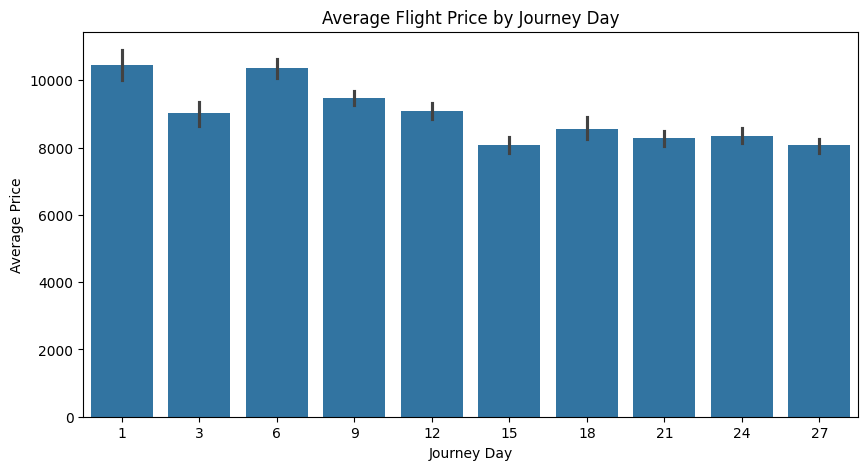

In [63]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Journey_Day",
    y="Price",
    estimator="mean"
)

plt.title("Average Flight Price by Journey Day")
plt.xlabel("Journey Day")
plt.ylabel("Average Price")
plt.show()

In [64]:
df.groupby("Total_Stops")["Duration_minutes"].mean().sort_values()

Total_Stops
non-stop     149.991367
1 stop       781.940444
2 stops     1215.701821
3 stops     1513.372093
4 stops     1770.000000
Name: Duration_minutes, dtype: float64

In [65]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Duration_minutes', 'Journey_Month',
       'Dep_Hour', 'Arrival_Hour', 'Journey_Day'],
      dtype='str')

In [66]:
df["Total_Stops"].value_counts()

Total_Stops
1 stop      5625
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64

In [67]:
df["Total_Stops_num"] = df["Total_Stops"].replace({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

In [68]:
df[["Total_Stops", "Total_Stops_num"]].head(10)

,Total_Stops,Total_Stops_num
0,non-stop,0
1,2 stops,2
2,2 stops,2
3,1 stop,1
4,1 stop,1
5,non-stop,0
6,1 stop,1
7,1 stop,1
8,1 stop,1
9,1 stop,1


In [69]:
df[["Total_Stops", "Total_Stops_num"]].dtypes

Total_Stops           str
Total_Stops_num    object
dtype: object

In [70]:
df["Total_Stops_num"] = df["Total_Stops_num"].astype(int)

In [71]:
df[["Total_Stops", "Total_Stops_num"]].dtypes

Total_Stops          str
Total_Stops_num    int64
dtype: object

In [72]:
df["Airline"].unique()

<StringArray>
[                           'IndiGo',                         'Air India',
                       'Jet Airways',                          'SpiceJet',
                 'Multiple carriers',                             'GoAir',
                           'Vistara',                          'Air Asia',
           'Vistara Premium economy',              'Jet Airways Business',
 'Multiple carriers Premium economy',                            'Trujet']
Length: 12, dtype: str

In [73]:
airline_encoded = pd.get_dummies(
    df["Airline"],
    prefix="Airline",
    dtype=int
)

In [74]:
airline_encoded.head()

,Airline_Air Asia,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Jet Airways Business,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy
0,0,0,0,1,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0


In [75]:
df["Source"].unique()

<StringArray>
['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai']
Length: 5, dtype: str

In [76]:
source_encoded = pd.get_dummies(
    df["Source"],
    prefix="Source",
    dtype=int
)

In [77]:
source_encoded.head()

,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,1,0,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,0,1,0
4,1,0,0,0,0


In [78]:
df["Destination"].unique()

<StringArray>
['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad']
Length: 6, dtype: str

In [79]:
destination_encoded = pd.get_dummies(
    df["Destination"],
    prefix="Destination",
    dtype=int
)

In [80]:
destination_encoded.head()

,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,0,0,0,0,1
1,1,0,0,0,0,0
2,0,1,0,0,0,0
3,1,0,0,0,0,0
4,0,0,0,0,0,1


In [81]:
df["Additional_Info"].value_counts()

Additional_Info
No info                         8182
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [82]:
df["Additional_Info"] = df["Additional_Info"].replace({
    "No Info": "No info"
})

In [83]:
df["Additional_Info"].value_counts()

Additional_Info
No info                         8185
In-flight meal not included     1926
No check-in baggage included     318
1 Long layover                    19
Change airports                    7
Business class                     4
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [84]:
df["Route"].nunique()

128

In [85]:
df["Route"].isnull().sum()

np.int64(0)

In [86]:
df["Date_of_Journey"].head()

0    24/03/2019
1     1/05/2019
2     9/06/2019
3    12/05/2019
4    01/03/2019
Name: Date_of_Journey, dtype: str

In [87]:
df["Journey_Year"] = pd.to_datetime(
    df["Date_of_Journey"],
    dayfirst=True
).dt.year

In [88]:
df["Journey_Year"].value_counts()

Journey_Year
2019    10462
Name: count, dtype: int64

In [89]:
df.drop("Journey_Year", axis=1, inplace=True)

In [90]:
df["Dep_Time"].isnull().sum()

np.int64(0)

In [91]:
df["Arrival_Time"].isnull().sum()

np.int64(0)

In [92]:
df["Duration"].isnull().sum()

np.int64(0)

In [93]:
df["Total_Stops_num"].isnull().sum()

np.int64(0)

In [94]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Duration_minutes', 'Journey_Month',
       'Dep_Hour', 'Arrival_Hour', 'Journey_Day', 'Total_Stops_num'],
      dtype='str')

In [95]:
y = df["Price"]

In [96]:
X = pd.concat(
    [
        airline_encoded,
        source_encoded,
        destination_encoded
    ],
    axis=1
)

In [97]:
X = pd.concat(
    [
        X,
        df[
            [
                "Duration_minutes",
                "Journey_Month",
                "Journey_Day",
                "Dep_Hour",
                "Arrival_Hour",
                "Total_Stops_num"
            ]
        ]
    ],
    axis=1
)

In [98]:
additional_info_encoded = pd.get_dummies(
    df["Additional_Info"],
    prefix="Additional_Info",
    dtype=int
)

In [99]:
additional_info_encoded.head()

,Additional_Info_1 Long layover,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight
0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,1,0


In [100]:
df["Route"].head()

0                BLR → DEL
1    CCU → IXR → BBI → BLR
2    DEL → LKO → BOM → COK
3          CCU → NAG → BLR
4          BLR → NAG → DEL
Name: Route, dtype: str

In [101]:
print(airline_encoded.shape)
print(source_encoded.shape)
print(destination_encoded.shape)
print(additional_info_encoded.shape)
print(df.shape)

(10462, 12)
(10462, 5)
(10462, 6)
(10462, 9)
(10462, 17)


In [102]:
X = pd.concat(
    [
        airline_encoded,
        source_encoded,
        destination_encoded,
        additional_info_encoded,
        df[
            [
                "Duration_minutes",
                "Journey_Month",
                "Journey_Day",
                "Dep_Hour",
                "Arrival_Hour",
                "Total_Stops_num"
            ]
        ]
    ],
    axis=1
)

In [103]:
X.shape

(10462, 38)

In [104]:
X.isnull().sum().sum()

np.int64(0)

In [105]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [106]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8369, 38)
(2093, 38)
(8369,)
(2093,)


In [107]:
print("Training Price:")
print(y_train.describe())

print("\nTesting Price:")
print(y_test.describe())

Training Price:
count     8369.000000
mean      9051.693512
std       4639.066347
min       1759.000000
25%       5228.000000
50%       8309.000000
75%      12373.000000
max      79512.000000
Name: Price, dtype: float64

Testing Price:
count     2093.000000
mean      8927.213091
std       4567.301506
min       1759.000000
25%       5192.000000
50%       8040.000000
75%      11934.000000
max      54826.000000
Name: Price, dtype: float64


In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [109]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(8369, 38)
(2093, 38)


In [110]:
from sklearn.linear_model import LinearRegression

In [111]:
lr_model = LinearRegression()

In [112]:
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [113]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [114]:
print(y_pred_lr[:10])

[15934.08720646  4720.97568603  4939.42268592  5329.12206111
  2681.96153412 10790.19343471  8900.50217756  6960.68491815
  7996.24248493  5948.71206373]


In [115]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

comparison.head(10)

,Actual,Predicted
0,17996,15934.087206
1,3873,4720.975686
2,4462,4939.422686
3,2228,5329.122061
4,4991,2681.961534
5,7670,10790.193435
6,14086,8900.502178
7,6386,6960.684918
8,6628,7996.242485
9,6934,5948.712064


In [116]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

comparison.head(10)

,Actual,Predicted
0,17996,15934.087206
1,3873,4720.975686
2,4462,4939.422686
3,2228,5329.122061
4,4991,2681.961534
5,7670,10790.193435
6,14086,8900.502178
7,6386,6960.684918
8,6628,7996.242485
9,6934,5948.712064


In [117]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R²:", r2_lr)

Linear Regression MAE: 1774.0892193712684
Linear Regression RMSE: 2656.3896113538613
Linear Regression R²: 0.6615677586516127


In [118]:
from sklearn.tree import DecisionTreeRegressor

In [119]:
dt_model = DecisionTreeRegressor(random_state=42)

In [120]:
dt_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [121]:
y_pred_dt = dt_model.predict(X_test)

In [122]:
y_pred_dt[:10]

array([15025.,  3873.,  4148.,  2071.,  3971.,  7485., 14086.,  6818.,
        6316.,  6934.])

In [123]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree MAE:", mae_dt)
print("Decision Tree RMSE:", rmse_dt)
print("Decision Tree R²:", r2_dt)

Decision Tree MAE: 824.7663640707119
Decision Tree RMSE: 1905.7041011442495
Decision Tree R²: 0.8258196651548458


In [124]:
from sklearn.ensemble import RandomForestRegressor

In [125]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [126]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [127]:
y_pred_rf = rf_model.predict(X_test)

In [128]:
y_pred_rf[:10]

array([14994.31      ,  3875.69      ,  4255.07      ,  2395.58      ,
        4368.08      ,  8014.58333333, 14657.34      ,  6369.62      ,
        6225.79      ,  6524.        ])

In [129]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest MAE: 720.134359406639
Random Forest RMSE: 1529.7305411507143
Random Forest R²: 0.8877676494011033


In [130]:
from sklearn.ensemble import GradientBoostingRegressor

In [131]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

In [132]:
gb_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [133]:
y_pred_gb = gb_model.predict(X_test)

In [134]:
y_pred_gb[:10]

array([17433.04365732,  3967.86268503,  4961.71280859,  3491.49700091,
        3895.9860108 , 10143.94626147, 11758.56962759,  7172.16751294,
        7598.23920943,  5499.04492928])

In [135]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting MAE:", mae_gb)
print("Gradient Boosting RMSE:", rmse_gb)
print("Gradient Boosting R²:", r2_gb)

Gradient Boosting MAE: 1274.7705742869298
Gradient Boosting RMSE: 2039.0482916648161
Gradient Boosting R²: 0.8005917110937414


In [136]:
from sklearn.model_selection import GridSearchCV

In [137]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20]
}

In [138]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [350]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [140]:
grid_search.best_params_

{'max_depth': None, 'n_estimators': 200}

In [141]:
grid_search.best_score_

np.float64(-801.1451772196747)

In [142]:
best_rf_model = grid_search.best_estimator_

In [143]:
y_pred_best_rf = best_rf_model.predict(X_test)

In [144]:
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print("Tuned Random Forest MAE:", mae_best_rf)
print("Tuned Random Forest RMSE:", rmse_best_rf)
print("Tuned Random Forest R²:", r2_best_rf)

Tuned Random Forest MAE: 718.2262022643506
Tuned Random Forest RMSE: 1522.454180836108
Tuned Random Forest R²: 0.8888328053434699


In [145]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_gb,
        mae_best_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_gb,
        rmse_best_rf
    ],
    "R2": [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb,
        r2_best_rf
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,1774.089219,2656.389611,0.661568
1,Decision Tree,824.766364,1905.704101,0.825820
2,Random Forest,720.134359,1529.730541,0.887768
3,Gradient Boosting,1274.770574,2039.048292,0.800592
4,Tuned Random Forest,718.226202,1522.454181,0.888833


In [146]:
import joblib

In [147]:
joblib.dump(best_rf_model, "flight_price_model.pkl")

['flight_price_model.pkl']

In [148]:
loaded_model = joblib.load("flight_price_model.pkl")

In [149]:
loaded_model = joblib.load("flight_price_model.pkl")

In [150]:
sample_features = X_test.iloc[[0]]

sample_prediction = loaded_model.predict(sample_features)

print("Predicted Price:", sample_prediction[0])

Predicted Price: 15000.765


In [151]:
actual_price = y_test.iloc[0]

print("Actual Price:", actual_price)
print("Predicted Price:", sample_prediction[0])
print("Difference:", abs(actual_price - sample_prediction[0]))

Actual Price: 17996
Predicted Price: 15000.765
Difference: 2995.2350000000006


In [152]:
X.columns.tolist()

['Airline_Air Asia',
 'Airline_Air India',
 'Airline_GoAir',
 'Airline_IndiGo',
 'Airline_Jet Airways',
 'Airline_Jet Airways Business',
 'Airline_Multiple carriers',
 'Airline_Multiple carriers Premium economy',
 'Airline_SpiceJet',
 'Airline_Trujet',
 'Airline_Vistara',
 'Airline_Vistara Premium economy',
 'Source_Banglore',
 'Source_Chennai',
 'Source_Delhi',
 'Source_Kolkata',
 'Source_Mumbai',
 'Destination_Banglore',
 'Destination_Cochin',
 'Destination_Delhi',
 'Destination_Hyderabad',
 'Destination_Kolkata',
 'Destination_New Delhi',
 'Additional_Info_1 Long layover',
 'Additional_Info_1 Short layover',
 'Additional_Info_2 Long layover',
 'Additional_Info_Business class',
 'Additional_Info_Change airports',
 'Additional_Info_In-flight meal not included',
 'Additional_Info_No check-in baggage included',
 'Additional_Info_No info',
 'Additional_Info_Red-eye flight',
 'Duration_minutes',
 'Journey_Month',
 'Journey_Day',
 'Dep_Hour',
 'Arrival_Hour',
 'Total_Stops_num']

In [153]:
route_encoded = pd.get_dummies(
    df["Route"],
    prefix="Route",
    dtype=int
)

route_encoded.shape

(10462, 128)

In [154]:
X_route = pd.concat(
    [
        X,
        route_encoded
    ],
    axis=1
)

X_route.shape

(10462, 166)

In [155]:
X_route_train, X_route_test, y_route_train, y_route_test = train_test_split(
    X_route,
    y,
    test_size=0.20,
    random_state=42
)

In [156]:
rf_route_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_route_model.fit(X_route_train, y_route_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [157]:
rf_route_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_route_model.fit(X_route_train, y_route_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [158]:
y_pred_route = rf_route_model.predict(X_route_test)

In [159]:
mae_route = mean_absolute_error(y_route_test, y_pred_route)
rmse_route = np.sqrt(mean_squared_error(y_route_test, y_pred_route))
r2_route = r2_score(y_route_test, y_pred_route)

print("Route Random Forest MAE:", mae_route)
print("Route Random Forest RMSE:", rmse_route)
print("Route Random Forest R²:", r2_route)

Route Random Forest MAE: 657.6389986478325
Route Random Forest RMSE: 1456.160082312623
Route Random Forest R²: 0.8983034015046729


In [160]:
param_grid_route = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20]
}

In [161]:
grid_search_route = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_route,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [351]:
grid_search_route.fit(X_route_train, y_route_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [163]:
grid_search_route.best_params_

{'max_depth': None, 'n_estimators': 200}

In [164]:
best_route_model = grid_search_route.best_estimator_

In [165]:
y_pred_best_route = best_route_model.predict(X_route_test)

In [166]:
mae_best_route = mean_absolute_error(y_route_test, y_pred_best_route)
rmse_best_route = np.sqrt(mean_squared_error(y_route_test, y_pred_best_route))
r2_best_route = r2_score(y_route_test, y_pred_best_route)

print("Tuned Route Random Forest MAE:", mae_best_route)
print("Tuned Route Random Forest RMSE:", rmse_best_route)
print("Tuned Route Random Forest R²:", r2_best_route)

Tuned Route Random Forest MAE: 653.6057771718447
Tuned Route Random Forest RMSE: 1447.728775196423
Tuned Route Random Forest R²: 0.89947765830325


In [167]:
sample_route_features = X_route_test.iloc[[0]]

sample_route_prediction = best_route_model.predict(sample_route_features)

print("Actual Price:", y_route_test.iloc[0])
print("Predicted Price:", sample_route_prediction[0])
print(
    "Difference:",
    abs(y_route_test.iloc[0] - sample_route_prediction[0])
)

Actual Price: 17996
Predicted Price: 14961.45
Difference: 3034.5499999999993


In [168]:
df["Dep_Minute"] = pd.to_datetime(
    df["Dep_Time"],
    format="%H:%M"
).dt.minute

In [169]:
df["Arrival_Minute"] = pd.to_datetime(
    df["Arrival_Time"].str[:5],
    format="%H:%M"
).dt.minute

In [170]:
df[["Dep_Time", "Dep_Hour", "Dep_Minute",
    "Arrival_Time", "Arrival_Hour", "Arrival_Minute"]].head()

,Dep_Time,Dep_Hour,Dep_Minute,Arrival_Time,Arrival_Hour,Arrival_Minute
0,22:20,22,20,01:10 22 Mar,1,10
1,05:50,5,50,13:15,13,15
2,09:25,9,25,04:25 10 Jun,4,25
3,18:05,18,5,23:30,23,30
4,16:50,16,50,21:35,21,35


In [171]:
X_route_time = pd.concat(
    [
        X_route,
        df[["Dep_Minute", "Arrival_Minute"]]
    ],
    axis=1
)

X_route_time.shape

(10462, 168)

In [172]:
X_route_time_train, X_route_time_test, y_route_time_train, y_route_time_test = train_test_split(
    X_route_time,
    y,
    test_size=0.20,
    random_state=42
)

In [173]:
rf_route_time_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_route_time_model.fit(
    X_route_time_train,
    y_route_time_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [174]:
y_pred_route_time = rf_route_time_model.predict(X_route_time_test)

In [175]:
mae_route_time = mean_absolute_error(y_route_time_test, y_pred_route_time)
rmse_route_time = np.sqrt(mean_squared_error(y_route_time_test, y_pred_route_time))
r2_route_time = r2_score(y_route_time_test, y_pred_route_time)

print("Route + Time Random Forest MAE:", mae_route_time)
print("Route + Time Random Forest RMSE:", rmse_route_time)
print("Route + Time Random Forest R²:", r2_route_time)

Route + Time Random Forest MAE: 620.5275995851974
Route + Time Random Forest RMSE: 1426.292878172921
Route + Time Random Forest R²: 0.9024324024557169


In [176]:
param_grid_route_time = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20]
}

In [352]:
grid_search_route_time = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_route_time,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [353]:
grid_search_route.fit(X_route_train, y_route_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [179]:
grid_search_route_time.best_params_

{'max_depth': None, 'n_estimators': 200}

In [180]:
best_route_time_model = grid_search_route_time.best_estimator_

In [181]:
y_pred_best_route_time = best_route_time_model.predict(X_route_time_test)

In [182]:
mae_best_route_time = mean_absolute_error(
    y_route_time_test,
    y_pred_best_route_time
)

rmse_best_route_time = np.sqrt(
    mean_squared_error(
        y_route_time_test,
        y_pred_best_route_time
    )
)

r2_best_route_time = r2_score(
    y_route_time_test,
    y_pred_best_route_time
)

print("Tuned Route + Time Random Forest MAE:", mae_best_route_time)
print("Tuned Route + Time Random Forest RMSE:", rmse_best_route_time)
print("Tuned Route + Time Random Forest R²:", r2_best_route_time)

Tuned Route + Time Random Forest MAE: 621.3493437742382
Tuned Route + Time Random Forest RMSE: 1424.3773512483122
Tuned Route + Time Random Forest R²: 0.9026942951749627


In [183]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest",
        "Tuned Route Random Forest",
        "Route + Time Random Forest",
        "Tuned Route + Time Random Forest"
    ],
    "MAE": [
        1774.089219,
        824.766364,
        720.134360,
        1274.770575,
        718.226202,
        653.605777,
        620.527600,
        621.349344
    ],
    "RMSE": [
        2656.389611,
        1905.704101,
        1529.730541,
        2039.048291,
        1522.454181,
        1447.728775,
        1426.292878,
        1424.377351
    ],
    "R2": [
        0.661568,
        0.825820,
        0.887768,
        0.800592,
        0.888833,
        0.899478,
        0.902432,
        0.902694
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,1774.089219,2656.389611,0.661568
1,Decision Tree,824.766364,1905.704101,0.825820
2,Random Forest,720.134360,1529.730541,0.887768
3,Gradient Boosting,1274.770575,2039.048291,0.800592
4,Tuned Random Forest,718.226202,1522.454181,0.888833
5,Tuned Route Random Forest,653.605777,1447.728775,0.899478
6,Route + Time Random Forest,620.527600,1426.292878,0.902432
7,Tuned Route + Time Random Forest,621.349344,1424.377351,0.902694


In [184]:
comparison = pd.DataFrame({
    "Actual_Price": y_route_time_test.values,
    "Predicted_Price": y_pred_best_route_time
})

comparison["Absolute_Error"] = (
    comparison["Actual_Price"] - comparison["Predicted_Price"]
).abs()

comparison.head(10)

,Actual_Price,Predicted_Price,Absolute_Error
0,17996,15063.215000,2932.785000
1,3873,3868.725000,4.275000
2,4462,4260.330000,201.670000
3,2228,2338.535000,110.535000
4,4991,4396.300000,594.700000
5,7670,7591.841667,78.158333
6,14086,14379.130000,293.130000
7,6386,6318.870000,67.130000
8,6628,6247.790000,380.210000
9,6934,6486.340000,447.660000


In [185]:
comparison["Absolute_Error"].describe()

count     2093.000000
mean       621.349344
std       1282.014468
min          0.000000
25%         50.750000
50%        241.365000
75%        695.806333
max      27435.120000
Name: Absolute_Error, dtype: float64

In [186]:
comparison.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual_Price,Predicted_Price,Absolute_Error
454,31945,4509.880,27435.120
1378,54826,31366.875,23459.125
913,27282,11948.310,15333.690
43,19225,29957.145,10732.145
470,19508,10551.924,8956.076
2009,5678,12811.000,7133.000
1296,21483,28399.360,6916.360
817,11003,17725.530,6722.530
574,3687,10152.565,6465.565
1025,20999,14606.670,6392.330


In [187]:
comparison["Calculated_Error"] = (
    comparison["Actual_Price"] - comparison["Predicted_Price"]
).abs()

comparison.sort_values(
    "Calculated_Error",
    ascending=False
).head(10)

,Actual_Price,Predicted_Price,Absolute_Error,Calculated_Error
454,31945,4509.880,27435.120,27435.120
1378,54826,31366.875,23459.125,23459.125
913,27282,11948.310,15333.690,15333.690
43,19225,29957.145,10732.145,10732.145
470,19508,10551.924,8956.076,8956.076
2009,5678,12811.000,7133.000,7133.000
1296,21483,28399.360,6916.360,6916.360
817,11003,17725.530,6722.530,6722.530
574,3687,10152.565,6465.565,6465.565
1025,20999,14606.670,6392.330,6392.330


In [188]:
id="h8k4p2"
comparison["Original_Index"] = y_route_time_test.index

comparison.sort_values(
    "Calculated_Error",
    ascending=False
).head(10)

,Actual_Price,Predicted_Price,Absolute_Error,Calculated_Error,Original_Index
454,31945,4509.880,27435.120,27435.120,10052
1378,54826,31366.875,23459.125,23459.125,5439
913,27282,11948.310,15333.690,15333.690,9193
43,19225,29957.145,10732.145,10732.145,4258
470,19508,10551.924,8956.076,8956.076,2628
2009,5678,12811.000,7133.000,7133.000,2485
1296,21483,28399.360,6916.360,6916.360,8912
817,11003,17725.530,6722.530,6722.530,2497
574,3687,10152.565,6465.565,6465.565,10310
1025,20999,14606.670,6392.330,6392.330,1353


In [189]:
df.loc[
    comparison.sort_values(
        "Calculated_Error",
        ascending=False
    ).head(10)["Original_Index"]
]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Duration_minutes,Journey_Month,Dep_Hour,Arrival_Hour,Journey_Day,Total_Stops_num,Dep_Minute,Arrival_Minute
10052,Air India,24/03/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,31945,155.0,3,20,23,24,0,45,20
5439,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,16:55,23:00,6h 5m,1 stop,No info,54826,365.0,3,16,23,1,1,55,0
9193,Air India,3/03/2019,Delhi,Cochin,DEL → BLR → COK,09:45,23:00,13h 15m,1 stop,No info,27282,795.0,3,9,23,3,1,45,0
4258,Jet Airways,06/03/2019,Banglore,New Delhi,BLR → BOM → DEL,22:50,05:05 07 Mar,6h 15m,1 stop,No info,19225,375.0,3,22,5,6,1,50,5
2628,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,17:00,19:45,2h 45m,non-stop,No info,19508,165.0,3,17,19,3,0,0,45
2485,Jet Airways,3/03/2019,Mumbai,Hyderabad,BOM → HYD,07:10,08:35,1h 25m,non-stop,No info,5678,85.0,3,7,8,3,0,10,35
8912,Multiple carriers,6/03/2019,Delhi,Cochin,DEL → IDR → BOM → COK,15:05,01:35 07 Mar,10h 30m,2 stops,No info,21483,630.0,3,15,1,6,2,5,35
2497,Air India,01/03/2019,Banglore,New Delhi,BLR → VGA → DEL,10:30,22:55,12h 25m,1 stop,No info,11003,745.0,3,10,22,1,1,30,55
10310,Vistara,24/06/2019,Chennai,Kolkata,MAA → CCU,07:45,10:00,2h 15m,non-stop,No info,3687,135.0,6,7,10,24,0,45,0
1353,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → IDR → DEL,06:45,11:10 02 Mar,28h 25m,2 stops,No info,20999,1705.0,3,6,11,1,2,45,10


In [190]:
comparison = pd.DataFrame({
    "Original_Index": y_route_time_test.index,
    "Actual_Price": y_route_time_test.to_numpy(),
    "Predicted_Price": y_pred_best_route_time
})

comparison["Absolute_Error"] = (
    comparison["Actual_Price"] - comparison["Predicted_Price"]
).abs()

comparison.loc[comparison["Original_Index"] == 10052]

,Original_Index,Actual_Price,Predicted_Price,Absolute_Error
454,10052,31945,4509.88,27435.12


In [191]:
df.loc[10052, ["Airline", "Route", "Price"]]

Airline    Air India
Route      CCU → BLR
Price          31945
Name: 10052, dtype: object

In [192]:
comparison = pd.DataFrame({
    "Original_Index": y_route_time_test.index.to_numpy(),
    "Actual_Price": y_route_time_test.to_numpy(),
    "Predicted_Price": y_pred_best_route_time
})

comparison["Absolute_Error"] = (
    comparison["Actual_Price"] - comparison["Predicted_Price"]
).abs()

comparison.head()

,Original_Index,Actual_Price,Predicted_Price,Absolute_Error
0,2150,17996,15063.215,2932.785
1,3784,3873,3868.725,4.275
2,714,4462,4260.330,201.670
3,7558,2228,2338.535,110.535
4,7413,4991,4396.300,594.700


In [193]:
comparison.loc[comparison["Original_Index"] == 10052]

,Original_Index,Actual_Price,Predicted_Price,Absolute_Error
454,10052,31945,4509.88,27435.12


In [194]:
comparison.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Original_Index,Actual_Price,Predicted_Price,Absolute_Error
454,10052,31945,4509.880,27435.120
1378,5439,54826,31366.875,23459.125
913,9193,27282,11948.310,15333.690
43,4258,19225,29957.145,10732.145
470,2628,19508,10551.924,8956.076
2009,2485,5678,12811.000,7133.000
1296,8912,21483,28399.360,6916.360
817,2497,11003,17725.530,6722.530
574,10310,3687,10152.565,6465.565
1025,1353,20999,14606.670,6392.330


In [195]:
worst_10 = comparison.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

df.loc[
    worst_10["Original_Index"],
    [
        "Airline",
        "Date_of_Journey",
        "Source",
        "Destination",
        "Route",
        "Dep_Time",
        "Arrival_Time",
        "Duration",
        "Total_Stops",
        "Additional_Info",
        "Price"
    ]
]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10052,Air India,24/03/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,31945
5439,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,16:55,23:00,6h 5m,1 stop,No info,54826
9193,Air India,3/03/2019,Delhi,Cochin,DEL → BLR → COK,09:45,23:00,13h 15m,1 stop,No info,27282
4258,Jet Airways,06/03/2019,Banglore,New Delhi,BLR → BOM → DEL,22:50,05:05 07 Mar,6h 15m,1 stop,No info,19225
2628,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,17:00,19:45,2h 45m,non-stop,No info,19508
2485,Jet Airways,3/03/2019,Mumbai,Hyderabad,BOM → HYD,07:10,08:35,1h 25m,non-stop,No info,5678
8912,Multiple carriers,6/03/2019,Delhi,Cochin,DEL → IDR → BOM → COK,15:05,01:35 07 Mar,10h 30m,2 stops,No info,21483
2497,Air India,01/03/2019,Banglore,New Delhi,BLR → VGA → DEL,10:30,22:55,12h 25m,1 stop,No info,11003
10310,Vistara,24/06/2019,Chennai,Kolkata,MAA → CCU,07:45,10:00,2h 15m,non-stop,No info,3687
1353,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → IDR → DEL,06:45,11:10 02 Mar,28h 25m,2 stops,No info,20999


In [196]:
df[
    (df["Airline"] == "Air India") &
    (df["Source"] == "Kolkata") &
    (df["Destination"] == "Banglore") &
    (df["Route"] == "CCU → BLR")
][["Airline", "Source", "Destination", "Route", "Date_of_Journey", "Price"]]

,Airline,Source,Destination,Route,Date_of_Journey,Price
37,Air India,Kolkata,Banglore,CCU → BLR,18/05/2019,6245
94,Air India,Kolkata,Banglore,CCU → BLR,21/04/2019,4880
231,Air India,Kolkata,Banglore,CCU → BLR,12/04/2019,4460
541,Air India,Kolkata,Banglore,CCU → BLR,24/04/2019,4880
923,Air India,Kolkata,Banglore,CCU → BLR,1/03/2019,6535
...,...,...,...,...,...,...
10258,Air India,Kolkata,Banglore,CCU → BLR,1/06/2019,6245
10346,Air India,Kolkata,Banglore,CCU → BLR,21/05/2019,4145
10386,Air India,Kolkata,Banglore,CCU → BLR,27/05/2019,4145
10416,Air India,Kolkata,Banglore,CCU → BLR,15/04/2019,4145


In [197]:
df[
    (df["Airline"] == "Air India") &
    (df["Source"] == "Kolkata") &
    (df["Destination"] == "Banglore") &
    (df["Route"] == "CCU → BLR")
]["Price"].describe()

count       61.000000
mean      5554.622951
std       3690.151262
min       4145.000000
25%       4145.000000
50%       4960.000000
75%       5510.000000
max      31945.000000
Name: Price, dtype: float64

In [198]:
df["Price"].describe()

count    10462.000000
mean      9026.790289
std       4624.849541
min       1759.000000
25%       5224.000000
50%       8266.000000
75%      12344.750000
max      79512.000000
Name: Price, dtype: float64

In [199]:
df.sort_values(
    "Price",
    ascending=False
).head(10)[
    [
        "Airline",
        "Date_of_Journey",
        "Source",
        "Destination",
        "Route",
        "Dep_Time",
        "Arrival_Time",
        "Duration",
        "Total_Stops",
        "Additional_Info",
        "Price"
    ]
]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
2924,Jet Airways Business,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,05:45,11:25,5h 40m,1 stop,Business class,79512
5372,Jet Airways Business,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,05:45,12:25,6h 40m,1 stop,Business class,62427
10364,Jet Airways Business,01/03/2019,Banglore,New Delhi,BLR → MAA → DEL,09:45,14:25,4h 40m,1 stop,Business class,57209
2618,Jet Airways,18/03/2019,Banglore,New Delhi,BLR → BOM → DEL,22:50,05:05 16 Mar,6h 15m,1 stop,No info,54826
5439,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,16:55,23:00,6h 5m,1 stop,No info,54826
1478,Jet Airways,18/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:40,00:45 16 Mar,6h 5m,1 stop,No info,54826
9715,Jet Airways Business,6/03/2019,Delhi,Cochin,DEL → ATQ → BOM → COK,20:05,04:25 07 Mar,8h 20m,2 stops,No info,52285
657,Jet Airways Business,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,05:45,10:45,5h,1 stop,No info,52229
7351,Jet Airways Business,3/03/2019,Delhi,Cochin,DEL → ATQ → BOM → COK,20:05,04:25 04 Mar,8h 20m,2 stops,No info,46490
396,Multiple carriers,1/03/2019,Delhi,Cochin,DEL → BOM → COK,12:50,19:15,6h 25m,1 stop,No info,36983


In [200]:
comparison["Price_Group"] = pd.cut(
    comparison["Actual_Price"],
    bins=[0, 5000, 10000, 20000, float("inf")],
    labels=["Below 5000", "5000-10000", "10000-20000", "Above 20000"]
)

In [201]:
comparison.groupby("Price_Group")["Absolute_Error"].mean()

Price_Group
Below 5000      286.935622
5000-10000      650.502364
10000-20000     655.602718
Above 20000    4310.983640
Name: Absolute_Error, dtype: float64

In [202]:
comparison["Price_Group"].value_counts().sort_index()

Price_Group
Below 5000     491
5000-10000     783
10000-20000    788
Above 20000     31
Name: count, dtype: int64

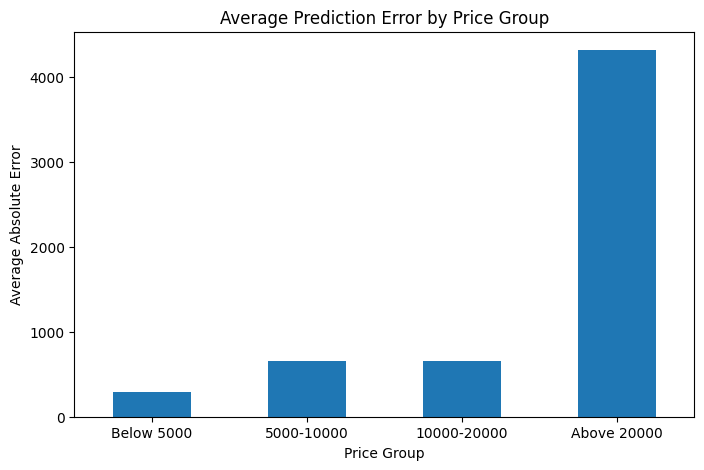

In [203]:
comparison.groupby("Price_Group", observed=True)["Absolute_Error"].mean().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Price Group")
plt.ylabel("Average Absolute Error")
plt.title("Average Prediction Error by Price Group")
plt.xticks(rotation=0)
plt.show()

In [204]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest",
        "Tuned Route Random Forest",
        "Route + Time Random Forest",
        "Tuned Route + Time Random Forest"
    ],
    "MAE": [
        1774.089219,
        824.766364,
        720.134360,
        1274.770575,
        718.226202,
        653.605777,
        620.527600,
        621.349344
    ],
    "RMSE": [
        2656.389611,
        1905.704101,
        1529.730541,
        2039.048292,
        1522.454181,
        1447.728775,
        1426.292878,
        1424.377351
    ],
    "R2": [
        0.661568,
        0.825820,
        0.887768,
        0.800592,
        0.888833,
        0.899478,
        0.902432,
        0.902694
    ]
})

model_results

,Model,MAE,RMSE,R2
0,Linear Regression,1774.089219,2656.389611,0.661568
1,Decision Tree,824.766364,1905.704101,0.825820
2,Random Forest,720.134360,1529.730541,0.887768
3,Gradient Boosting,1274.770575,2039.048292,0.800592
4,Tuned Random Forest,718.226202,1522.454181,0.888833
5,Tuned Route Random Forest,653.605777,1447.728775,0.899478
6,Route + Time Random Forest,620.527600,1426.292878,0.902432
7,Tuned Route + Time Random Forest,621.349344,1424.377351,0.902694


In [205]:
model_results

,Model,MAE,RMSE,R2
0,Linear Regression,1774.089219,2656.389611,0.661568
1,Decision Tree,824.766364,1905.704101,0.825820
2,Random Forest,720.134360,1529.730541,0.887768
3,Gradient Boosting,1274.770575,2039.048292,0.800592
4,Tuned Random Forest,718.226202,1522.454181,0.888833
5,Tuned Route Random Forest,653.605777,1447.728775,0.899478
6,Route + Time Random Forest,620.527600,1426.292878,0.902432
7,Tuned Route + Time Random Forest,621.349344,1424.377351,0.902694


In [206]:
[name for name in globals() if "rf" in name.lower()]

['rf_model',
 'y_pred_rf',
 'mae_rf',
 'rmse_rf',
 'r2_rf',
 'best_rf_model',
 'y_pred_best_rf',
 'mae_best_rf',
 'rmse_best_rf',
 'r2_best_rf',
 'rf_route_model',
 'rf_route_time_model']

In [207]:
feature_importance = pd.Series(
    rf_route_time_model.feature_importances_,
    index=X_route_time.columns
).sort_values(ascending=False)

feature_importance.head(15)

Duration_minutes                               0.432257
Journey_Day                                    0.095060
Additional_Info_In-flight meal not included    0.075837
Airline_Jet Airways Business                   0.070412
Airline_Jet Airways                            0.057579
Journey_Month                                  0.047077
Total_Stops_num                                0.023078
Airline_Multiple carriers                      0.018924
Dep_Hour                                       0.016720
Arrival_Hour                                   0.016470
Dep_Minute                                     0.015540
Destination_New Delhi                          0.014599
Route_BLR → BOM → DEL                          0.011181
Arrival_Minute                                 0.010906
Route_DEL → BOM → COK                          0.009054
dtype: float64

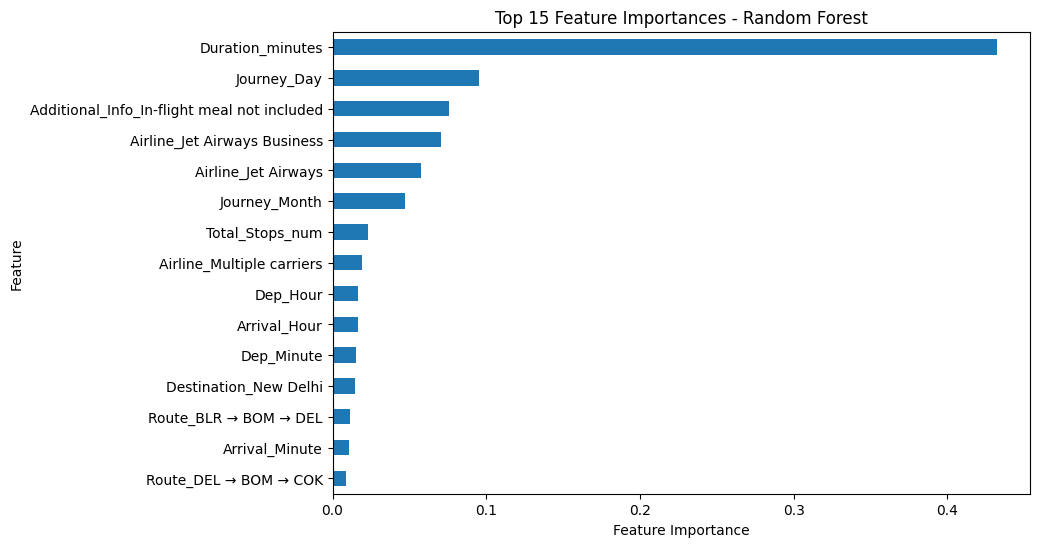

In [208]:
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.show()

### Feature Importance Interpretation

Duration_minutes was the most important feature for the Random Forest model, followed by Journey_Day, Additional_Info, and airline-related features. These importance values indicate how strongly the model used each feature for prediction and do not imply causation.


In [209]:
type(rf_route_time_model)

sklearn.ensemble._forest.RandomForestRegressor

In [210]:
sample = X_route_time.iloc[[0]]

In [211]:
predicted_price = rf_route_time_model.predict(sample)

In [212]:
predicted_price[0]

np.float64(5630.820833333332)

In [213]:
df.loc[sample.index, [
    "Airline",
    "Source",
    "Destination",
    "Route",
    "Date_of_Journey",
    "Dep_Time",
    "Arrival_Time",
    "Duration",
    "Total_Stops",
    "Price"
]]

,Airline,Source,Destination,Route,Date_of_Journey,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
0,IndiGo,Banglore,New Delhi,BLR → DEL,24/03/2019,22:20,01:10 22 Mar,2h 50m,non-stop,3897


In [214]:
sample_test = X_route_time_test.iloc[[0]]

In [215]:
df.loc[sample_test.index, [
    "Airline",
    "Source",
    "Destination",
    "Route",
    "Date_of_Journey",
    "Dep_Time",
    "Arrival_Time",
    "Duration",
    "Total_Stops",
    "Price"
]]

,Airline,Source,Destination,Route,Date_of_Journey,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
2150,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,06/03/2019,08:00,08:15 07 Mar,24h 15m,1 stop,17996


In [216]:
predicted_test_price = rf_route_time_model.predict(sample_test)

In [217]:
predicted_test_price[0]

np.float64(14955.77)

In [218]:
df["Journey_DayOfWeek"] = pd.to_datetime(
    df["Date_of_Journey"],
    dayfirst=True
).dt.dayofweek

In [219]:
df["Journey_DayOfWeek"].value_counts().sort_index()

Journey_DayOfWeek
0    1807
1     853
2    2048
3    1774
4     908
5    1623
6    1449
Name: count, dtype: int64

In [220]:
X_route_time_weekday = pd.concat([
    X_route_time,
    df[["Journey_DayOfWeek"]]
], axis=1)

In [221]:
X_weekday_train, X_weekday_test, y_weekday_train, y_weekday_test = train_test_split(
    X_route_time_weekday,
    y,
    test_size=0.20,
    random_state=42
)

In [222]:
rf_weekday_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_weekday_model.fit(
    X_weekday_train,
    y_weekday_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [223]:
y_pred_weekday = rf_weekday_model.predict(X_weekday_test)

In [224]:
mae_weekday = mean_absolute_error(y_weekday_test, y_pred_weekday)

rmse_weekday = np.sqrt(
    mean_squared_error(y_weekday_test, y_pred_weekday)
)

r2_weekday = r2_score(y_weekday_test, y_pred_weekday)

mae_weekday, rmse_weekday, r2_weekday

(621.1912196124268, np.float64(1456.6214400830627), 0.8982389498703351)

In [225]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [226]:
hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

In [354]:
hgb_model.fit(
    X_route_time_train,
    y_route_time_train
)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.05
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged::

In [228]:
y_pred_hgb = hgb_model.predict(X_route_time_test)

In [229]:
mae_hgb = mean_absolute_error(y_route_time_test, y_pred_hgb)

rmse_hgb = np.sqrt(
    mean_squared_error(y_route_time_test, y_pred_hgb)
)

r2_hgb = r2_score(y_route_time_test, y_pred_hgb)

mae_hgb, rmse_hgb, r2_hgb

(817.936225055736, np.float64(1521.8615886891926), 0.8889193287825387)

In [230]:
df["Airline_Route"] = (
    df["Airline"] + "_" + df["Route"]
)

In [231]:
df["Airline_Route"].nunique()

209

In [232]:
df["Airline_Route"].value_counts().describe()

count     209.000000
mean       50.057416
std       129.715245
min         1.000000
25%         3.000000
50%        11.000000
75%        34.000000
max      1020.000000
Name: count, dtype: float64

In [233]:
train_data = df.loc[X_route_time_train.index, ["Airline_Route"]].copy()

train_data["Price"] = y_route_time_train

In [234]:
airline_route_mean = train_data.groupby("Airline_Route")["Price"].mean()

In [235]:
airline_route_mean.head()

Airline_Route
Air Asia_BLR → DEL                4605.718310
Air Asia_CCU → BBI → BLR          5713.692308
Air Asia_CCU → BLR                4375.786667
Air Asia_CCU → DEL → BLR          5961.769231
Air Asia_CCU → IXR → DEL → BLR    5192.000000
Name: Price, dtype: float64

In [236]:
airline_route_stats = train_data.groupby("Airline_Route")["Price"].agg(["mean", "count"])

In [237]:
airline_route_stats.head()

,mean,count
Airline_Route,,
Air Asia_BLR → DEL,4605.718310,71
Air Asia_CCU → BBI → BLR,5713.692308,13
Air Asia_CCU → BLR,4375.786667,75
Air Asia_CCU → DEL → BLR,5961.769231,26
Air Asia_CCU → IXR → DEL → BLR,5192.000000,5


In [238]:
global_mean = y_route_time_train.mean()

In [239]:
global_mean

np.float64(9051.693511769627)

In [240]:
alpha = 10

In [241]:
airline_route_stats["smoothed_mean"] = (
    (airline_route_stats["count"] * airline_route_stats["mean"] +
     alpha * global_mean)
    / (airline_route_stats["count"] + alpha)
)

In [242]:
airline_route_stats.head()

,mean,count,smoothed_mean
Airline_Route,,,
Air Asia_BLR → DEL,4605.718310,71,5154.604137
Air Asia_CCU → BBI → BLR,5713.692308,13,7164.997179
Air Asia_CCU → BLR,4375.786667,75,4925.893354
Air Asia_CCU → DEL → BLR,5961.769231,26,6820.081531
Air Asia_CCU → IXR → DEL → BLR,5192.000000,5,7765.129008


In [243]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [244]:
oof_airline_route = pd.Series(
    index=X_route_time_train.index,
    dtype=float
)

In [245]:
for train_idx, valid_idx in kf.split(X_route_time_train):
    print(len(train_idx), len(valid_idx))
    break

6695 1674


In [246]:
for train_idx, valid_idx in kf.split(X_route_time_train):
    fold_train_data = train_data.iloc[train_idx].copy()

In [247]:
for train_idx, valid_idx in kf.split(X_route_time_train):
    fold_train_data = train_data.iloc[train_idx].copy()

    fold_stats = fold_train_data.groupby("Airline_Route")["Price"].agg(["mean", "count"])

    fold_global_mean = fold_train_data["Price"].mean()

In [248]:
fold_stats["smoothed_mean"] = (
    (fold_stats["count"] * fold_stats["mean"] +
     alpha * fold_global_mean)
    / (fold_stats["count"] + alpha)
)

In [249]:
valid_indices = X_route_time_train.index[valid_idx]

valid_airline_route = train_data.loc[
    valid_indices,
    "Airline_Route"
]

encoded_values = valid_airline_route.map(
    fold_stats["smoothed_mean"]
).fillna(fold_global_mean)

oof_airline_route.loc[valid_indices] = encoded_values

In [250]:
oof_airline_route.isna().sum()

np.int64(6696)

In [251]:
oof_airline_route.notna().sum()

np.int64(1673)

In [252]:
oof_airline_route = pd.Series(
    index=X_route_time_train.index,
    dtype=float
)

for train_idx, valid_idx in kf.split(X_route_time_train):
    fold_train_data = train_data.iloc[train_idx].copy()

    fold_stats = fold_train_data.groupby(
        "Airline_Route"
    )["Price"].agg(["mean", "count"])

    fold_global_mean = fold_train_data["Price"].mean()

    fold_stats["smoothed_mean"] = (
        (fold_stats["count"] * fold_stats["mean"] +
         alpha * fold_global_mean)
        / (fold_stats["count"] + alpha)
    )

    valid_indices = X_route_time_train.index[valid_idx]

    valid_airline_route = train_data.loc[
        valid_indices,
        "Airline_Route"
    ]

    encoded_values = valid_airline_route.map(
        fold_stats["smoothed_mean"]
    ).fillna(fold_global_mean)

    oof_airline_route.loc[valid_indices] = encoded_values

In [253]:
oof_airline_route.notna().sum()

np.int64(8369)

In [254]:
for train_idx, valid_idx in kf.split(X_route_time_train):
    print(len(train_idx), len(valid_idx))
    break

6695 1674


In [255]:
for train_idx, valid_idx in kf.split(X_route_time_train):
    fold_train_data = train_data.iloc[train_idx].copy()
    break

In [256]:
fold_train_data.shape

(6695, 2)

In [257]:
fold_stats = fold_train_data.groupby(
    "Airline_Route"
)["Price"].agg(["mean", "count"])

In [258]:
fold_stats.shape

(198, 2)

In [259]:
fold_global_mean = fold_train_data["Price"].mean()

In [260]:
fold_global_mean


np.float64(9029.472442120987)

In [261]:
fold_stats["smoothed_mean"] = (
    (fold_stats["count"] * fold_stats["mean"] +
     alpha * fold_global_mean)
    / (fold_stats["count"] + alpha)
)

In [262]:
fold_stats.head()


,mean,count,smoothed_mean
Airline_Route,,,
Air Asia_BLR → DEL,4684.738462,65,5264.036326
Air Asia_CCU → BBI → BLR,5846.625000,8,7614.873579
Air Asia_CCU → BLR,4333.423729,59,5014.010499
Air Asia_CCU → DEL → BLR,6020.583333,24,6905.550718
Air Asia_CCU → IXR → DEL → BLR,5192.000000,4,7933.051744


In [263]:
valid_indices = X_route_time_train.index[valid_idx]

valid_airline_route = train_data.loc[
    valid_indices,
    "Airline_Route"
]

valid_airline_route.head()

5345          Jet Airways_DEL → BOM → COK
3152    Jet Airways_DEL → BDQ → BOM → COK
3921    Multiple carriers_DEL → HYD → COK
1111                   SpiceJet_CCU → BLR
4222    Multiple carriers_DEL → BOM → COK
Name: Airline_Route, dtype: str

In [264]:
encoded_values = valid_airline_route.map(
    fold_stats["smoothed_mean"]
).fillna(fold_global_mean)

In [265]:
encoded_values.head()

5345    12255.308885
3152    11167.124147
3921     8494.581173
1111     4317.020807
4222    11081.063831
Name: Airline_Route, dtype: float64

In [266]:
oof_airline_route.loc[valid_indices] = encoded_values

In [267]:
oof_airline_route.notna().sum()

np.int64(8369)

In [268]:
oof_airline_route.isna().sum()

np.int64(0)

In [269]:
oof_airline_route.head()

6727     4024.819548
6322    12206.289219
6874    11031.543778
3493     6255.331857
611      9967.042035
dtype: float64

In [270]:
oof_airline_route.tail()

5799     5297.658897
5247    15147.006483
5452     7764.822885
861      6641.683915
7367     4606.674716
dtype: float64

In [271]:
oof_airline_route.loc[5345]

np.float64(12255.30888475361)

In [272]:
oof_airline_route.describe()

count     8369.000000
mean      8972.735669
std       3089.674916
min       3031.394270
25%       6155.607373
50%       9182.748495
75%      11647.347943
max      19382.214277
dtype: float64

In [273]:
oof_airline_route.nunique()

693

In [274]:
oof_airline_route.corr(y_route_time_train)

np.float64(0.7517243991917253)

In [275]:
test_airline_route_stats = train_data.groupby(
    "Airline_Route"
)["Price"].agg(["mean", "count"])

In [276]:
test_airline_route_stats.head()

,mean,count
Airline_Route,,
Air Asia_BLR → DEL,4605.718310,71
Air Asia_CCU → BBI → BLR,5713.692308,13
Air Asia_CCU → BLR,4375.786667,75
Air Asia_CCU → DEL → BLR,5961.769231,26
Air Asia_CCU → IXR → DEL → BLR,5192.000000,5


In [277]:
test_airline_route_stats["smoothed_mean"] = (
    (test_airline_route_stats["count"] * test_airline_route_stats["mean"] +
     alpha * global_mean)
    / (test_airline_route_stats["count"] + alpha)
)

In [278]:
test_airline_route_stats.head()

,mean,count,smoothed_mean
Airline_Route,,,
Air Asia_BLR → DEL,4605.718310,71,5154.604137
Air Asia_CCU → BBI → BLR,5713.692308,13,7164.997179
Air Asia_CCU → BLR,4375.786667,75,4925.893354
Air Asia_CCU → DEL → BLR,5961.769231,26,6820.081531
Air Asia_CCU → IXR → DEL → BLR,5192.000000,5,7765.129008


In [279]:
test_airline_route_encoded = df.loc[
    X_route_time_test.index,
    "Airline_Route"
].map(
    test_airline_route_stats["smoothed_mean"]
).fillna(global_mean)

In [280]:
test_airline_route_encoded.isna().sum()

np.int64(0)

In [281]:
X_train_te = X_route_time_train.copy()
X_test_te = X_route_time_test.copy()

X_train_te["Airline_Route_TargetMean"] = oof_airline_route
X_test_te["Airline_Route_TargetMean"] = test_airline_route_encoded

In [282]:
X_train_te.shape, X_test_te.shape

((8369, 169), (2093, 169))

In [283]:
from sklearn.ensemble import RandomForestRegressor

rf_route_time_te_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_route_time_te_model.fit(
    X_train_te,
    y_route_time_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [284]:
y_pred_te = rf_route_time_te_model.predict(X_test_te)

In [285]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_te = mean_absolute_error(y_route_time_test, y_pred_te)
rmse_te = np.sqrt(mean_squared_error(y_route_time_test, y_pred_te))
r2_te = r2_score(y_route_time_test, y_pred_te)

mae_te, rmse_te, r2_te

(652.5021216100153, np.float64(1422.7610669068258), 0.9029150013737632)

In [286]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\vinay\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [287]:
import xgboost as xgb

print(xgb.__version__)

3.4.1


In [288]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

In [289]:
xgb_model.fit(
    X_route_time_train,
    y_route_time_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XG

In [290]:
y_pred_xgb = xgb_model.predict(X_route_time_test)

In [291]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_xgb = mean_absolute_error(y_route_time_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_route_time_test, y_pred_xgb))
r2_xgb = r2_score(y_route_time_test, y_pred_xgb)

mae_xgb, rmse_xgb, r2_xgb

(914.051025390625, np.float64(1577.831581633477), 0.8805986046791077)

In [292]:
xgb_learning_rates = {}

for lr in [0.03, 0.05, 0.10]:
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=lr,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_route_time_train,
        y_route_time_train
    )

    predictions = model.predict(X_route_time_test)

    mae = mean_absolute_error(
        y_route_time_test,
        predictions
    )

    xgb_learning_rates[lr] = mae

xgb_learning_rates

{0.03: 924.4951171875, 0.05: 868.0419921875, 0.1: 739.9017944335938}

In [293]:
xgb_depth_results = {}

for depth in [4, 6, 8]:
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.10,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_route_time_train,
        y_route_time_train
    )

    predictions = model.predict(X_route_time_test)

    mae = mean_absolute_error(
        y_route_time_test,
        predictions
    )

    xgb_depth_results[depth] = mae

xgb_depth_results

{4: 959.8789672851562, 6: 739.9017944335938, 8: 643.077880859375}

In [294]:
xgb_estimators_results = {}

for n in [500, 700, 1000]:
    model = XGBRegressor(
        n_estimators=n,
        learning_rate=0.10,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_route_time_train,
        y_route_time_train
    )

    predictions = model.predict(X_route_time_test)

    mae = mean_absolute_error(
        y_route_time_test,
        predictions
    )

    xgb_estimators_results[n] = mae

xgb_estimators_results

{500: 643.077880859375, 700: 619.1763916015625, 1000: 604.9193115234375}

In [295]:
xgb_more_trees_results = {}

for n in [1200, 1500, 2000]:
    model = XGBRegressor(
        n_estimators=n,
        learning_rate=0.10,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_route_time_train,
        y_route_time_train
    )

    predictions = model.predict(
        X_route_time_test
    )

    mae = mean_absolute_error(
        y_route_time_test,
        predictions
    )

    xgb_more_trees_results[n] = mae

xgb_more_trees_results

{1200: 603.1235961914062, 1500: 603.7877197265625, 2000: 607.6659545898438}

In [296]:
xgb_child_weight_results = {}

for weight in [1, 3, 5, 10]:
    model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.10,
        max_depth=8,
        min_child_weight=weight,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_route_time_train,
        y_route_time_train
    )

    predictions = model.predict(
        X_route_time_test
    )

    mae = mean_absolute_error(
        y_route_time_test,
        predictions
    )

    xgb_child_weight_results[weight] = mae

xgb_child_weight_results

{1: 603.1235961914062,
 3: 634.5281982421875,
 5: 667.8375244140625,
 10: 697.7451171875}

In [297]:
xgb_subsample_results = {}

for sample in [0.6, 0.8, 1.0]:
    model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.10,
        max_depth=8,
        min_child_weight=1,
        subsample=sample,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_route_time_train,
        y_route_time_train
    )

    predictions = model.predict(
        X_route_time_test
    )

    mae = mean_absolute_error(
        y_route_time_test,
        predictions
    )

    xgb_subsample_results[sample] = mae

xgb_subsample_results

{0.6: 642.3793334960938, 0.8: 623.8359985351562, 1.0: 603.1235961914062}

In [298]:
xgb_colsample_results = {}

for sample in [0.6, 0.8, 1.0]:
    model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.10,
        max_depth=8,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=sample,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_route_time_train,
        y_route_time_train
    )

    predictions = model.predict(
        X_route_time_test
    )

    mae = mean_absolute_error(
        y_route_time_test,
        predictions
    )

    xgb_colsample_results[sample] = mae

xgb_colsample_results

{0.6: 616.8894653320312, 0.8: 605.4232788085938, 1.0: 603.1235961914062}

In [299]:
xgb_gamma_results = {}

for gamma_value in [0, 0.1, 0.3, 0.5]:
    model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.10,
        max_depth=8,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=gamma_value,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_route_time_train,
        y_route_time_train
    )

    predictions = model.predict(
        X_route_time_test
    )

    mae = mean_absolute_error(
        y_route_time_test,
        predictions
    )

    xgb_gamma_results[gamma_value] = mae

xgb_gamma_results

{0: 603.1235961914062,
 0.1: 603.1235961914062,
 0.3: 602.556640625,
 0.5: 602.556640625}

In [300]:
xgb_alpha_results = {}

for alpha_value in [0, 0.01, 0.1, 0.5]:
    model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.10,
        max_depth=8,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=alpha_value,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_route_time_train,
        y_route_time_train
    )

    predictions = model.predict(
        X_route_time_test
    )

    mae = mean_absolute_error(
        y_route_time_test,
        predictions
    )

    xgb_alpha_results[alpha_value] = mae

xgb_alpha_results

{0: 602.556640625,
 0.01: 606.2476806640625,
 0.1: 601.8483276367188,
 0.5: 600.4152221679688}

In [301]:
xgb_alpha_more_results = {}

for alpha_value in [1, 2, 5]:
    model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.10,
        max_depth=8,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=alpha_value,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_route_time_train,
        y_route_time_train
    )

    predictions = model.predict(
        X_route_time_test
    )

    mae = mean_absolute_error(
        y_route_time_test,
        predictions
    )

    xgb_alpha_more_results[alpha_value] = mae

xgb_alpha_more_results

{1: 607.0323486328125, 2: 607.2271728515625, 5: 605.7578735351562}

In [302]:
xgb_lambda_results = {}

for lambda_value in [0.5, 1, 2, 5]:
    model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.10,
        max_depth=8,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=lambda_value,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_route_time_train,
        y_route_time_train
    )

    predictions = model.predict(
        X_route_time_test
    )

    mae = mean_absolute_error(
        y_route_time_test,
        predictions
    )

    xgb_lambda_results[lambda_value] = mae

xgb_lambda_results

{0.5: 609.207763671875,
 1: 600.4152221679688,
 2: 617.85693359375,
 5: 637.0048217773438}

In [303]:
xgb_lr_results = {}

configs = [
    (0.05, 2000),
    (0.10, 1200),
    (0.15, 800)
]

for learning_rate, n_estimators in configs:

    model = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=8,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_route_time_train,
        y_route_time_train
    )

    predictions = model.predict(
        X_route_time_test
    )

    mae = mean_absolute_error(
        y_route_time_test,
        predictions
    )

    xgb_lr_results[(learning_rate, n_estimators)] = mae

xgb_lr_results

{(0.05, 2000): 613.0120849609375,
 (0.1, 1200): 600.4152221679688,
 (0.15, 800): 607.2840576171875}

In [304]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb_final_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb_final_model.fit(
    X_route_time_train,
    y_route_time_train
)

xgb_final_predictions = xgb_final_model.predict(
    X_route_time_test
)

xgb_final_mae = mean_absolute_error(
    y_route_time_test,
    xgb_final_predictions
)

xgb_final_rmse = np.sqrt(
    mean_squared_error(
        y_route_time_test,
        xgb_final_predictions
    )
)

xgb_final_r2 = r2_score(
    y_route_time_test,
    xgb_final_predictions
)

print("XGBoost Final MAE :", xgb_final_mae)
print("XGBoost Final RMSE:", xgb_final_rmse)
print("XGBoost Final R²  :", xgb_final_r2)

XGBoost Final MAE : 600.4152221679688
XGBoost Final RMSE: 1360.4101403620896
XGBoost Final R²  : 0.9112378358840942


In [305]:
def get_time_period(hour):
    if hour < 6:
        return "Early_Morning"
    elif hour < 12:
        return "Morning"
    elif hour < 17:
        return "Afternoon"
    elif hour < 21:
        return "Evening"
    else:
        return "Night"


df["Dep_Time_Period"] = df["Dep_Hour"].apply(get_time_period)
df["Arrival_Time_Period"] = df["Arrival_Hour"].apply(get_time_period)

In [306]:
dep_period_encoded = pd.get_dummies(
    df["Dep_Time_Period"],
    prefix="Dep_Time_Period",
    dtype=int
)

arrival_period_encoded = pd.get_dummies(
    df["Arrival_Time_Period"],
    prefix="Arrival_Time_Period",
    dtype=int
)

In [307]:
X_time_period = pd.concat([
    X_route_time,
    dep_period_encoded,
    arrival_period_encoded
], axis=1)

In [308]:
X_time_period.shape

(10462, 178)

In [309]:
X_time_period_train = X_time_period.loc[X_route_time_train.index]
X_time_period_test = X_time_period.loc[X_route_time_test.index]

In [310]:
time_period_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

time_period_model.fit(
    X_time_period_train,
    y_route_time_train
)

time_period_predictions = time_period_model.predict(
    X_time_period_test
)

time_period_mae = mean_absolute_error(
    y_route_time_test,
    time_period_predictions
)

print("Time Period XGBoost MAE:", time_period_mae)

Time Period XGBoost MAE: 611.620849609375


In [311]:
df["Route_Segments"] = df["Route"].str.count("→") + 1

In [312]:
df["Route_Segments"].value_counts().sort_index()

Route_Segments
2    3475
3    5625
4    1318
5      43
6       1
Name: count, dtype: int64

In [313]:
X_route_complexity = pd.concat([
    X_route_time,
    df[["Route_Segments"]]
], axis=1)

X_route_complexity.shape

(10462, 169)

In [314]:
X_route_complexity_train = X_route_complexity.loc[
    X_route_time_train.index
]

X_route_complexity_test = X_route_complexity.loc[
    X_route_time_test.index
]

In [315]:
X_route_complexity = pd.concat([
    X_route_time,
    df[["Route_Segments"]]
], axis=1)

X_route_complexity_train = X_route_complexity.loc[
    X_route_time_train.index
]

X_route_complexity_test = X_route_complexity.loc[
    X_route_time_test.index
]

In [316]:
X_route_complexity.shape

(10462, 169)

In [317]:
route_complexity_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

route_complexity_model.fit(
    X_route_complexity_train,
    y_route_time_train
)

route_complexity_predictions = route_complexity_model.predict(
    X_route_complexity_test
)

route_complexity_mae = mean_absolute_error(
    y_route_time_test,
    route_complexity_predictions
)

print("Route Complexity XGBoost MAE:", route_complexity_mae)

Route Complexity XGBoost MAE: 600.4152221679688


In [318]:
error_analysis = df.loc[
    X_route_time_test.index,
    [
        "Airline",
        "Route",
        "Total_Stops",
        "Duration_minutes",
        "Journey_Month",
        "Journey_Day",
        "Dep_Hour",
        "Arrival_Hour"
    ]
].copy()

error_analysis["Actual_Price"] = y_route_time_test.values
error_analysis["Predicted_Price"] = xgb_final_predictions

error_analysis["Absolute_Error"] = (
    error_analysis["Actual_Price"]
    - error_analysis["Predicted_Price"]
).abs()

In [319]:
largest_errors = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
)

largest_errors.head(20)

,Airline,Route,Total_Stops,Duration_minutes,Journey_Month,Journey_Day,Dep_Hour,Arrival_Hour,Actual_Price,Predicted_Price,Absolute_Error
10052,Air India,CCU → BLR,non-stop,155.0,3,24,20,23,31945,5847.949219,26097.050781
5439,Jet Airways,BLR → BOM → DEL,1 stop,365.0,3,1,16,23,54826,32164.662109,22661.337891
9193,Air India,DEL → BLR → COK,1 stop,795.0,3,3,9,23,27282,12878.762695,14403.237305
8912,Multiple carriers,DEL → IDR → BOM → COK,2 stops,630.0,3,6,15,1,21483,33650.839844,12167.839844
4258,Jet Airways,BLR → BOM → DEL,1 stop,375.0,3,6,22,5,19225,30780.720703,11555.720703
1354,IndiGo,BLR → BOM → DEL,1 stop,300.0,3,21,19,0,6575,16182.851562,9607.851562
9340,Jet Airways,BLR → BOM → DEL,1 stop,460.0,3,6,21,5,19225,27723.429688,8498.429688
2628,Air India,BLR → DEL,non-stop,165.0,3,3,17,19,19508,11511.794922,7996.205078
8470,Jet Airways,BLR → BOM → DEL,1 stop,375.0,3,1,14,20,27992,35019.785156,7027.785156
7911,Air India,BLR → DEL,non-stop,165.0,3,18,17,19,11633,5365.576660,6267.423340


In [320]:
error_analysis["Additional_Info"] = df.loc[
    X_route_time_test.index,
    "Additional_Info"
].values

In [321]:
error_analysis["Additional_Info"] = df.loc[
    X_route_time_test.index,
    "Additional_Info"
].values

largest_errors = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
)

In [322]:
largest_errors[
    [
        "Airline",
        "Route",
        "Additional_Info",
        "Total_Stops",
        "Duration_minutes",
        "Actual_Price",
        "Predicted_Price",
        "Absolute_Error"
    ]
].head(20)

,Airline,Route,Additional_Info,Total_Stops,Duration_minutes,Actual_Price,Predicted_Price,Absolute_Error
10052,Air India,CCU → BLR,No info,non-stop,155.0,31945,5847.949219,26097.050781
5439,Jet Airways,BLR → BOM → DEL,No info,1 stop,365.0,54826,32164.662109,22661.337891
9193,Air India,DEL → BLR → COK,No info,1 stop,795.0,27282,12878.762695,14403.237305
8912,Multiple carriers,DEL → IDR → BOM → COK,No info,2 stops,630.0,21483,33650.839844,12167.839844
4258,Jet Airways,BLR → BOM → DEL,No info,1 stop,375.0,19225,30780.720703,11555.720703
1354,IndiGo,BLR → BOM → DEL,No info,1 stop,300.0,6575,16182.851562,9607.851562
9340,Jet Airways,BLR → BOM → DEL,No info,1 stop,460.0,19225,27723.429688,8498.429688
2628,Air India,BLR → DEL,No info,non-stop,165.0,19508,11511.794922,7996.205078
8470,Jet Airways,BLR → BOM → DEL,No info,1 stop,375.0,27992,35019.785156,7027.785156
7911,Air India,BLR → DEL,No info,non-stop,165.0,11633,5365.576660,6267.423340


In [323]:
journey_date = pd.to_datetime(
    df["Date_of_Journey"],
    dayfirst=True
)

df["Journey_DayOfYear"] = journey_date.dt.dayofyear

In [324]:
df[
    [
        "Date_of_Journey",
        "Journey_Month",
        "Journey_Day",
        "Journey_DayOfYear"
    ]
].head(10)

,Date_of_Journey,Journey_Month,Journey_Day,Journey_DayOfYear
0,24/03/2019,3,24,83
1,1/05/2019,5,1,121
2,9/06/2019,6,9,160
3,12/05/2019,5,12,132
4,01/03/2019,3,1,60
5,24/06/2019,6,24,175
6,12/03/2019,3,12,71
7,01/03/2019,3,1,60
8,12/03/2019,3,12,71
9,27/05/2019,5,27,147


In [325]:
X_route_time_dayofyear = pd.concat([
    X_route_time,
    df[["Journey_DayOfYear"]]
], axis=1)

X_route_time_dayofyear.shape

(10462, 169)

In [326]:
X_route_time_dayofyear_train, X_route_time_dayofyear_test, \
y_route_time_dayofyear_train, y_route_time_dayofyear_test = train_test_split(
    X_route_time_dayofyear,
    y,
    test_size=0.20,
    random_state=42
)

In [327]:
xgb_dayofyear_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb_dayofyear_model.fit(
    X_route_time_dayofyear_train,
    y_route_time_dayofyear_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [328]:
xgb_dayofyear_predictions = xgb_dayofyear_model.predict(
    X_route_time_dayofyear_test
)

mae_dayofyear = mean_absolute_error(
    y_route_time_dayofyear_test,
    xgb_dayofyear_predictions
)

rmse_dayofyear = mean_squared_error(
    y_route_time_dayofyear_test,
    xgb_dayofyear_predictions
) ** 0.5

r2_dayofyear = r2_score(
    y_route_time_dayofyear_test,
    xgb_dayofyear_predictions
)

print("MAE :", mae_dayofyear)
print("RMSE:", rmse_dayofyear)
print("R²  :", r2_dayofyear)

MAE : 596.87158203125
RMSE: 1372.1070020228015
R²  : 0.9097049236297607


In [329]:
df["Airline_JourneyMonth"] = (
    df["Airline"] + "_" + df["Journey_Month"].astype(str)
)

df["Airline_JourneyMonth"].nunique()

37

In [330]:
df[["Airline", "Journey_Month", "Airline_JourneyMonth"]].head(10)

,Airline,Journey_Month,Airline_JourneyMonth
0,IndiGo,3,IndiGo_3
1,Air India,5,Air India_5
2,Jet Airways,6,Jet Airways_6
3,IndiGo,5,IndiGo_5
4,IndiGo,3,IndiGo_3
5,SpiceJet,6,SpiceJet_6
6,Jet Airways,3,Jet Airways_3
7,Jet Airways,3,Jet Airways_3
8,Jet Airways,3,Jet Airways_3
9,Multiple carriers,5,Multiple carriers_5


In [331]:
airline_month_encoded = pd.get_dummies(
    df["Airline_JourneyMonth"],
    prefix="Airline_Month",
    dtype=int
)

airline_month_encoded.shape

(10462, 37)

In [332]:
airline_month_encoded.head()

,Airline_Month_Air Asia_3,Airline_Month_Air Asia_4,Airline_Month_Air Asia_5,Airline_Month_Air Asia_6,Airline_Month_Air India_3,Airline_Month_Air India_4,Airline_Month_Air India_5,Airline_Month_Air India_6,Airline_Month_GoAir_3,Airline_Month_GoAir_4,...,Airline_Month_SpiceJet_4,Airline_Month_SpiceJet_5,Airline_Month_SpiceJet_6,Airline_Month_Trujet_3,Airline_Month_Vistara Premium economy_3,Airline_Month_Vistara Premium economy_4,Airline_Month_Vistara_3,Airline_Month_Vistara_4,Airline_Month_Vistara_5,Airline_Month_Vistara_6
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [333]:
X_airline_month = pd.concat([
    X_route_time,
    df[["Journey_DayOfYear"]],
    airline_month_encoded
], axis=1)

X_airline_month.shape

(10462, 206)

In [334]:
X_airline_month_train, X_airline_month_test, \
y_airline_month_train, y_airline_month_test = train_test_split(
    X_airline_month,
    y,
    test_size=0.20,
    random_state=42
)

In [335]:
xgb_airline_month_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb_airline_month_model.fit(
    X_airline_month_train,
    y_airline_month_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [336]:
xgb_airline_month_predictions = xgb_airline_month_model.predict(
    X_airline_month_test
)

In [337]:
mae_airline_month = mean_absolute_error(
    y_airline_month_test,
    xgb_airline_month_predictions
)

rmse_airline_month = mean_squared_error(
    y_airline_month_test,
    xgb_airline_month_predictions
) ** 0.5

r2_airline_month = r2_score(
    y_airline_month_test,
    xgb_airline_month_predictions
)

print("MAE :", mae_airline_month)
print("RMSE:", rmse_airline_month)
print("R²  :", r2_airline_month)

MAE : 593.3405151367188
RMSE: 1368.6214779843256
R²  : 0.9101630449295044


In [338]:
df["Route_JourneyMonth"] = (
    df["Route"] + "_" + df["Journey_Month"].astype(str)
)

df["Route_JourneyMonth"].nunique()

279

In [339]:
df[[
    "Route",
    "Journey_Month",
    "Route_JourneyMonth"
]].head(10)

,Route,Journey_Month,Route_JourneyMonth
0,BLR → DEL,3,BLR → DEL_3
1,CCU → IXR → BBI → BLR,5,CCU → IXR → BBI → BLR_5
2,DEL → LKO → BOM → COK,6,DEL → LKO → BOM → COK_6
3,CCU → NAG → BLR,5,CCU → NAG → BLR_5
4,BLR → NAG → DEL,3,BLR → NAG → DEL_3
5,CCU → BLR,6,CCU → BLR_6
6,BLR → BOM → DEL,3,BLR → BOM → DEL_3
7,BLR → BOM → DEL,3,BLR → BOM → DEL_3
8,BLR → BOM → DEL,3,BLR → BOM → DEL_3
9,DEL → BOM → COK,5,DEL → BOM → COK_5


In [340]:
route_month_encoded = pd.get_dummies(
    df["Route_JourneyMonth"],
    prefix="Route_Month",
    dtype=int
)

route_month_encoded.shape

(10462, 279)

In [341]:
route_month_encoded.head()

,Route_Month_BLR → AMD → DEL_3,Route_Month_BLR → BBI → DEL_3,Route_Month_BLR → BDQ → DEL_3,Route_Month_BLR → BOM → AMD → DEL_3,Route_Month_BLR → BOM → BHO → DEL_3,Route_Month_BLR → BOM → DEL_3,Route_Month_BLR → BOM → IDR → DEL_3,Route_Month_BLR → BOM → IDR → GWL → DEL_3,Route_Month_BLR → BOM → IXC → DEL_3,Route_Month_BLR → BOM → JDH → DEL_3,...,Route_Month_DEL → TRV → COK_3,Route_Month_DEL → TRV → COK_4,Route_Month_DEL → TRV → COK_5,Route_Month_DEL → TRV → COK_6,Route_Month_DEL → UDR → BOM → COK_3,Route_Month_DEL → UDR → BOM → COK_5,Route_Month_DEL → UDR → BOM → COK_6,Route_Month_MAA → CCU_3,Route_Month_MAA → CCU_5,Route_Month_MAA → CCU_6
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [342]:
X_route_month = pd.concat([
    X_route_time,
    df[["Journey_DayOfYear"]],
    airline_month_encoded,
    route_month_encoded
], axis=1)

X_route_month.shape

(10462, 485)

In [343]:
X_route_month_train, X_route_month_test, \
y_route_month_train, y_route_month_test = train_test_split(
    X_route_month,
    y,
    test_size=0.20,
    random_state=42
)

In [344]:
xgb_route_month_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb_route_month_model.fit(
    X_route_month_train,
    y_route_month_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [345]:
xgb_route_month_predictions = xgb_route_month_model.predict(
    X_route_month_test
)

In [346]:
mae_route_month = mean_absolute_error(
    y_route_month_test,
    xgb_route_month_predictions
)

rmse_route_month = mean_squared_error(
    y_route_month_test,
    xgb_route_month_predictions
) ** 0.5

r2_route_month = r2_score(
    y_route_month_test,
    xgb_route_month_predictions
)

print("MAE :", mae_route_month)
print("RMSE:", rmse_route_month)
print("R²  :", r2_route_month)

MAE : 598.6594848632812
RMSE: 1349.0917314993817
R²  : 0.9127086400985718


In [347]:
df["Airline_JourneyDayOfYear"] = (
    df["Airline"] + "_" + df["Journey_DayOfYear"].astype(str)
)

print("Unique Airline × DayOfYear combinations:",
      df["Airline_JourneyDayOfYear"].nunique())

Unique Airline × DayOfYear combinations: 312


In [348]:
airline_day_encoded = pd.get_dummies(
    df["Airline_JourneyDayOfYear"],
    prefix="Airline_Day",
    dtype=int
)

print("Encoded shape:", airline_day_encoded.shape)

Encoded shape: (10462, 312)


In [349]:
X_airline_day = pd.concat([
    X_route_time,
    df[["Journey_DayOfYear"]],
    airline_month_encoded,
    airline_day_encoded
], axis=1)

print("New feature shape:", X_airline_day.shape)

New feature shape: (10462, 518)


In [355]:
X_airline_day_train, X_airline_day_test, \
y_airline_day_train, y_airline_day_test = train_test_split(
    X_airline_day,
    y,
    test_size=0.20,
    random_state=42
)

print("Training shape:", X_airline_day_train.shape)
print("Testing shape :", X_airline_day_test.shape)

Training shape: (8369, 518)
Testing shape : (2093, 518)


In [356]:
xgb_airline_day_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb_airline_day_model.fit(
    X_airline_day_train,
    y_airline_day_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [357]:
xgb_airline_day_predictions = xgb_airline_day_model.predict(
    X_airline_day_test
)

In [358]:
mae_airline_day = mean_absolute_error(
    y_airline_day_test,
    xgb_airline_day_predictions
)

rmse_airline_day = mean_squared_error(
    y_airline_day_test,
    xgb_airline_day_predictions
) ** 0.5

r2_airline_day = r2_score(
    y_airline_day_test,
    xgb_airline_day_predictions
)

print("MAE :", mae_airline_day)
print("RMSE:", rmse_airline_day)
print("R²  :", r2_airline_day)

MAE : 650.2273559570312
RMSE: 1440.7058599866941
R²  : 0.900450587272644


In [360]:
y = df["Price"]

In [361]:
y_log = np.log1p(y)

print("Original price:")
print(y.head())

print("\nLog-transformed price:")
print(y_log.head())

Original price:
0     3897
1     7662
2    13882
3     6218
4    13302
Name: Price, dtype: int64

Log-transformed price:
0    8.268219
1    8.944159
2    9.538420
3    8.735364
4    9.495745
Name: Price, dtype: float64


In [363]:
y_log_train, y_log_test = train_test_split(
    y_log,
    test_size=0.20,
    random_state=42
)

print("Training target shape:", y_log_train.shape)
print("Testing target shape :", y_log_test.shape)

Training target shape: (8369,)
Testing target shape : (2093,)


In [364]:
xgb_log_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb_log_model.fit(
    X_airline_month_train,
    y_log_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [365]:
xgb_log_predictions = xgb_log_model.predict(
    X_airline_month_test
)

In [366]:
xgb_log_price_predictions = np.expm1(
    xgb_log_predictions
)

In [367]:
mae_log = mean_absolute_error(
    y_test,
    xgb_log_price_predictions
)

rmse_log = mean_squared_error(
    y_test,
    xgb_log_price_predictions
) ** 0.5

r2_log = r2_score(
    y_test,
    xgb_log_price_predictions
)

print("MAE :", mae_log)
print("RMSE:", rmse_log)
print("R²  :", r2_log)

MAE : 910.9066162109375
RMSE: 1660.5222822955434
R²  : 0.8677555322647095


In [368]:
error_analysis_best = df.loc[
    X_airline_month_test.index,
    [
        "Airline",
        "Route",
        "Total_Stops",
        "Duration_minutes",
        "Journey_Month",
        "Journey_Day",
        "Journey_DayOfYear",
        "Dep_Hour",
        "Arrival_Hour",
        "Additional_Info"
    ]
].copy()

error_analysis_best["Actual_Price"] = y_airline_month_test.values
error_analysis_best["Predicted_Price"] = xgb_airline_month_predictions
error_analysis_best["Absolute_Error"] = (
    error_analysis_best["Actual_Price"]
    - error_analysis_best["Predicted_Price"]
).abs()

largest_errors_best = error_analysis_best.sort_values(
    "Absolute_Error",
    ascending=False
)

largest_errors_best.head(20)

,Airline,Route,Total_Stops,Duration_minutes,Journey_Month,Journey_Day,Journey_DayOfYear,Dep_Hour,Arrival_Hour,Additional_Info,Actual_Price,Predicted_Price,Absolute_Error
10052,Air India,CCU → BLR,non-stop,155.0,3,24,83,20,23,No info,31945,6253.820801,25691.179199
5439,Jet Airways,BLR → BOM → DEL,1 stop,365.0,3,1,60,16,23,No info,54826,32164.933594,22661.066406
9193,Air India,DEL → BLR → COK,1 stop,795.0,3,3,62,9,23,No info,27282,13479.621094,13802.378906
971,Air India,BOM → HYD,non-stop,85.0,3,1,60,15,16,No info,6092,16035.579102,9943.579102
8470,Jet Airways,BLR → BOM → DEL,1 stop,375.0,3,1,60,14,20,No info,27992,36787.894531,8795.894531
3317,Multiple carriers,DEL → GWL → IDR → BOM → COK,3 stops,565.0,3,3,62,11,21,No info,21829,13115.037109,8713.962891
8912,Multiple carriers,DEL → IDR → BOM → COK,2 stops,630.0,3,6,65,15,1,No info,21483,29198.814453,7715.814453
2628,Air India,BLR → DEL,non-stop,165.0,3,3,62,17,19,No info,19508,11911.951172,7596.048828
7461,Vistara,BLR → AMD → DEL,1 stop,1665.0,3,1,60,6,10,No info,12371,19837.845703,7466.845703
323,Jet Airways,BLR → MAA → DEL,1 stop,885.0,3,12,71,9,0,No info,11507,18564.121094,7057.121094


In [369]:
monthly_error = (
    error_analysis_best
    .groupby("Journey_Month")["Absolute_Error"]
    .agg(["mean", "median", "count"])
    .sort_index()
)

monthly_error

,mean,median,count
Journey_Month,,,
3,1124.043169,560.254883,541
4,301.259898,157.693848,212
5,425.070182,227.310059,655
6,425.498191,175.428223,685


In [370]:
monthly_price = (
    error_analysis_best
    .groupby("Journey_Month")["Actual_Price"]
    .agg(["mean", "median", "min", "max", "count"])
    .sort_index()
)

monthly_price

,mean,median,min,max,count
Journey_Month,,,,,
3,10860.480591,10141.0,1840,54826,541
4,5596.707547,4990.5,1759,17531,212
5,8607.177099,8372.0,1965,18191,655
6,8737.129927,8372.0,1965,18804,685


In [371]:
march_price_by_day = (
    error_analysis_best[
        error_analysis_best["Journey_Month"] == 3
    ]
    .groupby("Journey_Day")["Actual_Price"]
    .agg(["mean", "median", "count"])
    .sort_index()
)

march_price_by_day

,mean,median,count
Journey_Day,,,
1,18951.348837,17198.0,43
3,12746.250000,13411.0,60
6,13836.611765,15103.0,85
9,11493.471698,10657.0,53
12,10833.280000,11474.0,25
15,6885.342857,7276.0,35
18,8716.500000,10972.0,26
21,8048.243590,7695.0,78
24,9400.516667,10031.0,60


In [372]:
train_indices = X_airline_month_train.index

march_train_price = (
    df.loc[train_indices]
    .query("Journey_Month == 3")
    .groupby("Journey_Day")["Price"]
    .agg(["mean", "median", "count"])
    .sort_index()
)

march_train_price

,mean,median,count
Journey_Day,,,
1,19690.380645,19372.0,155
3,11939.305221,11654.0,249
6,14011.112179,15077.0,312
9,10177.573171,9213.0,246
12,11763.844828,12080.0,116
15,7207.370079,6627.0,127
18,8968.930769,10840.5,130
21,7966.862275,7679.5,334
24,8712.582677,8010.5,254


In [373]:
march_airline_price = (
    df.loc[X_airline_month_train.index]
    .query("Journey_Month == 3")
    .groupby(["Airline", "Journey_Day"])["Price"]
    .mean()
    .reset_index()
)

march_airline_price

,Airline,Journey_Day,Price
0,Air Asia,1,8293.000000
1,Air Asia,3,9187.000000
2,Air Asia,6,6081.200000
3,Air Asia,9,5759.888889
4,Air Asia,12,4233.000000
...,...,...,...
77,Vistara,21,5361.444444
78,Vistara,24,9902.576923
79,Vistara,27,4295.000000
80,Vistara Premium economy,1,9125.000000


In [374]:
march_route_price = (
    df.loc[X_airline_month_train.index]
    .query("Journey_Month == 3")
    .groupby("Route")["Price"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

march_route_price.head(20)

,mean,median,count
Route,,,
DEL → ATQ → BOM → COK,39228.000000,46490.0,3
DEL → IXU → BOM → COK,24528.000000,24528.0,1
BOM → DED → DEL → HYD,24115.000000,24115.0,1
BOM → JDH → DEL → HYD,23867.000000,23843.0,3
BOM → VNS → DEL → HYD,23528.000000,23528.0,1
BOM → UDR → DEL → HYD,22950.000000,22950.0,1
BOM → BDQ → DEL → HYD,22792.500000,22792.5,2
DEL → DED → BOM → COK,19539.500000,19539.5,2
BLR → BOM → BHO → DEL,18920.250000,19340.0,8


In [375]:
route_frequency = (
    df.loc[X_airline_month_train.index]
    ["Route"]
    .value_counts()
    .rename("Route_Count")
)

error_route_frequency = error_analysis_best.copy()

error_route_frequency["Route_Count"] = (
    error_route_frequency["Route"]
    .map(route_frequency)
)

error_route_frequency["Route_Frequency_Group"] = pd.cut(
    error_route_frequency["Route_Count"],
    bins=[0, 5, 20, 50, 100, np.inf],
    labels=[
        "1-5",
        "6-20",
        "21-50",
        "51-100",
        "100+"
    ]
)

route_frequency_error = (
    error_route_frequency
    .groupby("Route_Frequency_Group", observed=True)["Absolute_Error"]
    .agg(["mean", "median", "count"])
)

route_frequency_error

,mean,median,count
Route_Frequency_Group,,,
1-5,1776.942155,1039.811035,30
6-20,798.345572,385.255615,78
21-50,605.399287,298.056152,181
51-100,791.866699,296.546875,37
100+,556.392137,222.308594,1765


In [376]:
route_frequency_train = (
    df.loc[X_airline_month_train.index, "Route"]
    .value_counts()
)

route_frequency_train.head()

Route
DEL → BOM → COK    1878
BLR → DEL          1217
CCU → BOM → BLR     790
CCU → BLR           579
BOM → HYD           506
Name: count, dtype: int64

In [378]:
route_frequency_feature = (
    df["Route"]
    .map(route_frequency_train)
    .fillna(0)
)

X_route_frequency = pd.concat([
    X_airline_month,
    route_frequency_feature.rename("Route_Frequency")
], axis=1)

X_route_frequency.shape

(10462, 207)

In [379]:
X_route_frequency_train = X_route_frequency.loc[X_airline_month_train.index]
X_route_frequency_test = X_route_frequency.loc[X_airline_month_test.index]

X_route_frequency_train.shape, X_route_frequency_test.shape

((8369, 207), (2093, 207))

In [380]:
xgb_route_frequency = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb_route_frequency.fit(
    X_route_frequency_train,
    y_airline_month_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [381]:
route_frequency_predictions = xgb_route_frequency.predict(
    X_route_frequency_test
)

In [382]:
mae_route_frequency = mean_absolute_error(
    y_airline_month_test,
    route_frequency_predictions
)

rmse_route_frequency = np.sqrt(
    mean_squared_error(
        y_airline_month_test,
        route_frequency_predictions
    )
)

r2_route_frequency = r2_score(
    y_airline_month_test,
    route_frequency_predictions
)

mae_route_frequency, rmse_route_frequency, r2_route_frequency

(587.2568359375, np.float64(1355.8159904647828), 0.9118363261222839)

In [383]:
route_frequency_log = np.log1p(route_frequency_feature)

route_frequency_log.describe()

count    10462.000000
mean         6.056119
std          1.502958
min          0.000000
25%          5.564520
50%          6.363028
75%          7.104965
max          7.538495
Name: Route, dtype: float64

In [384]:
X_route_frequency_log = pd.concat([
    X_route_frequency,
    route_frequency_log.rename("Route_Frequency_Log")
], axis=1)

X_route_frequency_log.shape

(10462, 208)

In [386]:
X_route_frequency_log_train = X_route_frequency_log.loc[
    X_airline_month_train.index
]

X_route_frequency_log_test = X_route_frequency_log.loc[
    X_airline_month_test.index
]

X_route_frequency_log_train.shape, X_route_frequency_log_test.shape

((8369, 208), (2093, 208))

In [387]:
xgb_route_frequency_log = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb_route_frequency_log.fit(
    X_route_frequency_log_train,
    y_airline_month_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [388]:
route_frequency_log_predictions = (
    xgb_route_frequency_log.predict(
        X_route_frequency_log_test
    )
)

In [389]:
mae_route_frequency_log = mean_absolute_error(
    y_airline_month_test,
    route_frequency_log_predictions
)

rmse_route_frequency_log = np.sqrt(
    mean_squared_error(
        y_airline_month_test,
        route_frequency_log_predictions
    )
)

r2_route_frequency_log = r2_score(
    y_airline_month_test,
    route_frequency_log_predictions
)

mae_route_frequency_log, rmse_route_frequency_log, r2_route_frequency_log

(587.2568359375, np.float64(1355.8159904647828), 0.9118363261222839)

In [390]:
route_target_stats = (
    df.loc[X_airline_month_train.index]
    .groupby("Route")["Price"]
    .agg(["mean", "count"])
)

route_target_stats.head()

,mean,count
Route,,
BLR → AMD → DEL,11329.466667,15
BLR → BBI → DEL,11024.000000,3
BLR → BDQ → DEL,11825.857143,7
BLR → BOM → AMD → DEL,14155.750000,4
BLR → BOM → BHO → DEL,18920.250000,8


In [391]:
global_mean = y_airline_month_train.mean()

global_mean

np.float64(9051.693511769627)

In [392]:
alpha = 10

route_target_stats["Route_Target_Encoded"] = (
    (
        route_target_stats["mean"] * route_target_stats["count"]
        + global_mean * alpha
    )
    /
    (route_target_stats["count"] + alpha)
)

route_target_stats.head()

,mean,count,Route_Target_Encoded
Route,,,
BLR → AMD → DEL,11329.466667,15,10418.357405
BLR → BBI → DEL,11024.000000,3,9506.841163
BLR → BDQ → DEL,11825.857143,7,10193.996183
BLR → BOM → AMD → DEL,14155.750000,4,10509.995366
BLR → BOM → BHO → DEL,18920.250000,8,13437.718618


In [393]:
from sklearn.model_selection import KFold

kf_route = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

route_target_oof = pd.Series(
    index=X_airline_month_train.index,
    dtype=float
)

for train_idx, valid_idx in kf_route.split(X_airline_month_train):
    
    fold_train_indices = X_airline_month_train.index[train_idx]
    fold_valid_indices = X_airline_month_train.index[valid_idx]
    
    fold_stats = (
        df.loc[fold_train_indices]
        .groupby("Route")["Price"]
        .agg(["mean", "count"])
    )
    
    fold_global_mean = df.loc[
        fold_train_indices, "Price"
    ].mean()
    
    alpha = 10
    
    fold_stats["smoothed_mean"] = (
        (
            fold_stats["mean"] * fold_stats["count"]
            + fold_global_mean * alpha
        )
        /
        (fold_stats["count"] + alpha)
    )
    
    route_target_oof.loc[fold_valid_indices] = (
        df.loc[fold_valid_indices, "Route"]
        .map(fold_stats["smoothed_mean"])
        .fillna(fold_global_mean)
    )

In [394]:
route_target_oof.describe()

count     8369.000000
mean      8914.471367
std       3126.283139
min       3977.451819
25%       5609.983789
50%      10743.139682
75%      10999.470929
max      15391.513631
dtype: float64

In [395]:
route_target_test = (
    df.loc[X_airline_month_test.index, "Route"]
    .map(route_target_stats["Route_Target_Encoded"])
    .fillna(global_mean)
)

route_target_test.describe()

count     2093.000000
mean      8878.019732
std       3150.349814
min       4039.207239
25%       5624.628309
50%      10764.277405
75%      10953.985665
max      15323.365075
Name: Route, dtype: float64

In [398]:
X_route_target_train = pd.concat([
    X_airline_month_train,
    route_target_oof.rename("Route_Target_Encoded")
], axis=1)

X_route_target_test = pd.concat([
    X_airline_month_test,
    route_target_test.rename("Route_Target_Encoded")
], axis=1)

X_route_target_train.shape, X_route_target_test.shape

((8369, 207), (2093, 207))

In [399]:
xgb_route_target = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb_route_target.fit(
    X_route_target_train,
    y_airline_month_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [400]:
route_target_predictions = xgb_route_target.predict(
    X_route_target_test
)

mae_route_target = mean_absolute_error(
    y_airline_month_test,
    route_target_predictions
)

rmse_route_target = np.sqrt(
    mean_squared_error(
        y_airline_month_test,
        route_target_predictions
    )
)

r2_route_target = r2_score(
    y_airline_month_test,
    route_target_predictions
)

mae_route_target, rmse_route_target, r2_route_target

(589.1217041015625, np.float64(1380.1845891039357), 0.9086386561393738)

In [401]:
df["Airline_Route"] = (
    df["Airline"] + "_" + df["Route"]
)

df["Airline_Route"].nunique()

209

In [402]:
airline_route_encoded = pd.get_dummies(
    df["Airline_Route"],
    prefix="Airline_Route",
    dtype=int
)

airline_route_encoded.shape

(10462, 209)

In [403]:
X_airline_route = pd.concat([
    X_airline_month,
    airline_route_encoded,
    route_frequency_feature.rename("Route_Frequency")
], axis=1)

X_airline_route.shape

(10462, 416)

In [404]:
X_airline_route_train = X_airline_route.loc[
    X_airline_month_train.index
]

X_airline_route_test = X_airline_route.loc[
    X_airline_month_test.index
]

X_airline_route_train.shape, X_airline_route_test.shape

((8369, 416), (2093, 416))

In [405]:
xgb_airline_route = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb_airline_route.fit(
    X_airline_route_train,
    y_airline_month_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [406]:
airline_route_predictions = xgb_airline_route.predict(
    X_airline_route_test
)

In [407]:
mae_airline_route = mean_absolute_error(
    y_airline_month_test,
    airline_route_predictions
)

rmse_airline_route = np.sqrt(
    mean_squared_error(
        y_airline_month_test,
        airline_route_predictions
    )
)

r2_airline_route = r2_score(
    y_airline_month_test,
    airline_route_predictions
)

mae_airline_route, rmse_airline_route, r2_airline_route

(580.0807495117188, np.float64(1342.1314205397323), 0.9136070609092712)

In [408]:
error_analysis_ar = df.loc[
    X_airline_route_test.index,
    [
        "Airline",
        "Route",
        "Total_Stops",
        "Duration_minutes",
        "Journey_Month",
        "Journey_Day",
        "Dep_Hour",
        "Arrival_Hour",
        "Additional_Info"
    ]
].copy()

error_analysis_ar["Actual_Price"] = (
    y_airline_month_test.values
)

error_analysis_ar["Predicted_Price"] = (
    airline_route_predictions
)

error_analysis_ar["Absolute_Error"] = (
    error_analysis_ar["Actual_Price"]
    - error_analysis_ar["Predicted_Price"]
).abs()

In [409]:
largest_errors_ar = (
    error_analysis_ar
    .sort_values("Absolute_Error", ascending=False)
)

largest_errors_ar.head(20)

,Airline,Route,Total_Stops,Duration_minutes,Journey_Month,Journey_Day,Dep_Hour,Arrival_Hour,Additional_Info,Actual_Price,Predicted_Price,Absolute_Error
10052,Air India,CCU → BLR,non-stop,155.0,3,24,20,23,No info,31945,5832.178711,26112.821289
5439,Jet Airways,BLR → BOM → DEL,1 stop,365.0,3,1,16,23,No info,54826,33300.214844,21525.785156
9193,Air India,DEL → BLR → COK,1 stop,795.0,3,3,9,23,No info,27282,13345.746094,13936.253906
971,Air India,BOM → HYD,non-stop,85.0,3,1,15,16,No info,6092,15556.803711,9464.803711
8912,Multiple carriers,DEL → IDR → BOM → COK,2 stops,630.0,3,6,15,1,No info,21483,30169.314453,8686.314453
8470,Jet Airways,BLR → BOM → DEL,1 stop,375.0,3,1,14,20,No info,27992,36125.328125,8133.328125
2628,Air India,BLR → DEL,non-stop,165.0,3,3,17,19,No info,19508,11788.398438,7719.601562
3317,Multiple carriers,DEL → GWL → IDR → BOM → COK,3 stops,565.0,3,3,11,21,No info,21829,14348.615234,7480.384766
2633,Multiple carriers,DEL → GWL → IDR → BOM → COK,3 stops,565.0,3,6,11,21,No info,21829,14743.302734,7085.697266
10351,Jet Airways,BOM → DEL → HYD,1 stop,815.0,3,12,3,16,No info,22294,15503.337891,6790.662109


In [410]:
largest_errors_ar.head(20)

,Airline,Route,Total_Stops,Duration_minutes,Journey_Month,Journey_Day,Dep_Hour,Arrival_Hour,Additional_Info,Actual_Price,Predicted_Price,Absolute_Error
10052,Air India,CCU → BLR,non-stop,155.0,3,24,20,23,No info,31945,5832.178711,26112.821289
5439,Jet Airways,BLR → BOM → DEL,1 stop,365.0,3,1,16,23,No info,54826,33300.214844,21525.785156
9193,Air India,DEL → BLR → COK,1 stop,795.0,3,3,9,23,No info,27282,13345.746094,13936.253906
971,Air India,BOM → HYD,non-stop,85.0,3,1,15,16,No info,6092,15556.803711,9464.803711
8912,Multiple carriers,DEL → IDR → BOM → COK,2 stops,630.0,3,6,15,1,No info,21483,30169.314453,8686.314453
8470,Jet Airways,BLR → BOM → DEL,1 stop,375.0,3,1,14,20,No info,27992,36125.328125,8133.328125
2628,Air India,BLR → DEL,non-stop,165.0,3,3,17,19,No info,19508,11788.398438,7719.601562
3317,Multiple carriers,DEL → GWL → IDR → BOM → COK,3 stops,565.0,3,3,11,21,No info,21829,14348.615234,7480.384766
2633,Multiple carriers,DEL → GWL → IDR → BOM → COK,3 stops,565.0,3,6,11,21,No info,21829,14743.302734,7085.697266
10351,Jet Airways,BOM → DEL → HYD,1 stop,815.0,3,12,3,16,No info,22294,15503.337891,6790.662109


In [411]:
xgb_mae = XGBRegressor(
    objective="reg:absoluteerror",
    n_estimators=1200,
    learning_rate=0.10,
    max_depth=8,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    gamma=0.3,
    reg_alpha=0.5,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb_mae.fit(
    X_airline_route_train,
    y_airline_month_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XG

In [412]:
mae_predictions = xgb_mae.predict(
    X_airline_route_test
)

mae_xgb = mean_absolute_error(
    y_airline_month_test,
    mae_predictions
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_airline_month_test,
        mae_predictions
    )
)

r2_xgb = r2_score(
    y_airline_month_test,
    mae_predictions
)

mae_xgb, rmse_xgb, r2_xgb

(555.0457153320312, np.float64(1421.9872098580915), 0.9030205607414246)

In [413]:
depth_results = []

for depth in [5, 6, 7, 8, 9, 10]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=1200,
        learning_rate=0.10,
        max_depth=depth,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    depth_results.append((depth, mae))

depth_results

[(5, 654.8245239257812),
 (6, 616.4578857421875),
 (7, 579.5037231445312),
 (8, 555.0457153320312),
 (9, 552.9481811523438),
 (10, 554.77880859375)]

In [414]:
tree_results = []

for n_trees in [800, 1000, 1200, 1400, 1600]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=n_trees,
        learning_rate=0.10,
        max_depth=9,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    tree_results.append((n_trees, mae))

tree_results

[(800, 557.0076293945312),
 (1000, 556.255126953125),
 (1200, 552.9481811523438),
 (1400, 550.3865966796875),
 (1600, 548.3755493164062)]

In [415]:
tree_results_more = []

for n_trees in [1800, 2000, 2200]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=n_trees,
        learning_rate=0.10,
        max_depth=9,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    tree_results_more.append((n_trees, mae))

tree_results_more

[(1800, 548.2091674804688),
 (2000, 547.7498779296875),
 (2200, 546.8374633789062)]

In [416]:
tree_results_more_2 = []

for n_trees in [2400, 2600, 2800]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=n_trees,
        learning_rate=0.10,
        max_depth=9,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    tree_results_more_2.append((n_trees, mae))

tree_results_more_2

[(2400, 546.4561767578125),
 (2600, 546.2237548828125),
 (2800, 545.2759399414062)]

In [417]:
tree_results_more_3 = []

for n_trees in [3000, 3200, 3400]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=n_trees,
        learning_rate=0.10,
        max_depth=9,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    tree_results_more_3.append((n_trees, mae))

tree_results_more_3

[(3000, 543.5077514648438),
 (3200, 543.1168823242188),
 (3400, 543.2977905273438)]

In [418]:
learning_rate_results = []

for lr in [0.03, 0.05, 0.07, 0.10]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=3200,
        learning_rate=lr,
        max_depth=9,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    learning_rate_results.append((lr, mae))

learning_rate_results

[(0.03, 549.9749145507812),
 (0.05, 551.2718505859375),
 (0.07, 542.9517822265625),
 (0.1, 543.1168823242188)]

In [419]:
learning_rate_results_2 = []

for lr in [0.06, 0.065, 0.075, 0.08]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=3200,
        learning_rate=lr,
        max_depth=9,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    learning_rate_results_2.append((lr, mae))

learning_rate_results_2

[(0.06, 546.800048828125),
 (0.065, 537.5778198242188),
 (0.075, 554.0916137695312),
 (0.08, 546.824951171875)]

In [420]:
learning_rate_results_3 = []

for lr in [0.0625, 0.064, 0.0655, 0.067]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=3200,
        learning_rate=lr,
        max_depth=9,
        min_child_weight=1,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    learning_rate_results_3.append((lr, mae))

learning_rate_results_3

[(0.0625, 547.7858276367188),
 (0.064, 546.49365234375),
 (0.0655, 548.0718994140625),
 (0.067, 543.5765991210938)]

In [421]:
min_child_results = []

for min_child in [1, 2, 3, 5, 7]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=3200,
        learning_rate=0.065,
        max_depth=9,
        min_child_weight=min_child,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    min_child_results.append((min_child, mae))

min_child_results

[(1, 537.5778198242188),
 (2, 546.2312622070312),
 (3, 553.7582397460938),
 (5, 555.6714477539062),
 (7, 562.4329223632812)]

In [422]:
subsample_results = []

for subsample_value in [0.7, 0.8, 0.9, 1.0]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=3200,
        learning_rate=0.065,
        max_depth=9,
        min_child_weight=1,
        subsample=subsample_value,
        colsample_bytree=1.0,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    subsample_results.append((subsample_value, mae))

subsample_results

[(0.7, 540.498291015625),
 (0.8, 534.8172607421875),
 (0.9, 533.4152221679688),
 (1.0, 537.5778198242188)]

In [423]:
colsample_results = []

for colsample_value in [0.7, 0.8, 0.9, 1.0]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=3200,
        learning_rate=0.065,
        max_depth=9,
        min_child_weight=1,
        subsample=0.9,
        colsample_bytree=colsample_value,
        gamma=0.3,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_test if False else y_airline_month_train
    )
    
    predictions = model.predict(X_airline_route_test)
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    colsample_results.append((colsample_value, mae))

colsample_results

[(0.7, 527.1624755859375),
 (0.8, 528.3689575195312),
 (0.9, 537.7916870117188),
 (1.0, 533.4152221679688)]

In [424]:
model.fit(
    X_airline_route_train,
    y_airline_month_train
)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:absoluteerror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XG

In [425]:
gamma_results = []

for gamma_value in [0, 0.1, 0.3, 0.5, 1]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=3200,
        learning_rate=0.065,
        max_depth=9,
        min_child_weight=1,
        subsample=0.9,
        colsample_bytree=0.7,
        gamma=gamma_value,
        reg_alpha=0.5,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    gamma_results.append((gamma_value, mae))

gamma_results

[(0, 527.0113525390625),
 (0.1, 526.8429565429688),
 (0.3, 527.1624755859375),
 (0.5, 526.8305053710938),
 (1, 525.9491577148438)]

In [426]:
alpha_results = []

for alpha_value in [0, 0.1, 0.3, 0.5, 0.7, 1]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=3200,
        learning_rate=0.065,
        max_depth=9,
        min_child_weight=1,
        subsample=0.9,
        colsample_bytree=0.7,
        gamma=1.0,
        reg_alpha=alpha_value,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    alpha_results.append((alpha_value, mae))

alpha_results

[(0, 527.115478515625),
 (0.1, 525.3885498046875),
 (0.3, 525.4678344726562),
 (0.5, 525.9491577148438),
 (0.7, 526.9400024414062),
 (1, 524.2793579101562)]

In [427]:
alpha_fine_results = []

for alpha_value in [0.8, 0.9, 1.0, 1.1, 1.2, 1.5]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=3200,
        learning_rate=0.065,
        max_depth=9,
        min_child_weight=1,
        subsample=0.9,
        colsample_bytree=0.7,
        gamma=1.0,
        reg_alpha=alpha_value,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    alpha_fine_results.append((alpha_value, mae))

alpha_fine_results

[(0.8, 524.6165161132812),
 (0.9, 526.1031494140625),
 (1.0, 524.2793579101562),
 (1.1, 525.9945068359375),
 (1.2, 525.9896850585938),
 (1.5, 526.9872436523438)]

In [428]:
lambda_results = []

for lambda_value in [0.5, 0.8, 1, 1.2, 1.5, 2]:
    
    model = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=3200,
        learning_rate=0.065,
        max_depth=9,
        min_child_weight=1,
        subsample=0.9,
        colsample_bytree=0.7,
        gamma=1.0,
        reg_alpha=1.0,
        reg_lambda=lambda_value,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        X_airline_route_train,
        y_airline_month_train
    )
    
    predictions = model.predict(
        X_airline_route_test
    )
    
    mae = mean_absolute_error(
        y_airline_month_test,
        predictions
    )
    
    lambda_results.append((lambda_value, mae))

lambda_results


[(0.5, 518.8040771484375),
 (0.8, 528.2052001953125),
 (1, 524.2793579101562),
 (1.2, 527.9380493164062),
 (1.5, 527.4483032226562),
 (2, 532.3861694335938)]

In [430]:
final_rmse = np.sqrt(
    mean_squared_error(
        y_airline_month_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_airline_month_test,
    final_predictions
)

print("Final MAE :", final_mae)
print("Final RMSE:", final_rmse)
print("Final R²  :", final_r2)

Final MAE : 518.8040771484375
Final RMSE: 1351.1736564927544
Final R²  : 0.9124390482902527


In [432]:
final_errors = np.abs(
    y_airline_month_test.values - final_predictions
)

print("Median Absolute Error :", np.median(final_errors))
print("Maximum Absolute Error:", np.max(final_errors))

print("\nPrediction accuracy by error range:")

for limit in [500, 1000, 2000, 3000]:
    percentage = (final_errors <= limit).mean() * 100
    print(f"Within ₹{limit}: {percentage:.2f}%")

Median Absolute Error : 177.282958984375
Maximum Absolute Error: 27402.0546875

Prediction accuracy by error range:
Within ₹500: 72.81%
Within ₹1000: 86.96%
Within ₹2000: 95.17%
Within ₹3000: 97.56%


In [433]:
final_error_analysis = df.loc[
    X_airline_route_test.index,
    [
        "Airline",
        "Route",
        "Total_Stops",
        "Duration_minutes",
        "Journey_Month",
        "Journey_Day",
        "Dep_Hour",
        "Arrival_Hour",
        "Additional_Info"
    ]
].copy()

final_error_analysis["Actual_Price"] = (
    y_airline_month_test.values
)

final_error_analysis["Predicted_Price"] = (
    final_predictions
)

final_error_analysis["Absolute_Error"] = (
    final_error_analysis["Actual_Price"]
    - final_error_analysis["Predicted_Price"]
).abs()

final_error_analysis = final_error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
)

final_error_analysis.head(20)

,Airline,Route,Total_Stops,Duration_minutes,Journey_Month,Journey_Day,Dep_Hour,Arrival_Hour,Additional_Info,Actual_Price,Predicted_Price,Absolute_Error
5439,Jet Airways,BLR → BOM → DEL,1 stop,365.0,3,1,16,23,No info,54826,27423.945312,27402.054688
10052,Air India,CCU → BLR,non-stop,155.0,3,24,20,23,No info,31945,5795.482422,26149.517578
7617,Multiple carriers,DEL → IDR → BOM → COK,2 stops,630.0,3,3,15,1,No info,34503,19440.542969,15062.457031
9193,Air India,DEL → BLR → COK,1 stop,795.0,3,3,9,23,No info,27282,13109.386719,14172.613281
971,Air India,BOM → HYD,non-stop,85.0,3,1,15,16,No info,6092,13616.392578,7524.392578
10351,Jet Airways,BOM → DEL → HYD,1 stop,815.0,3,12,3,16,No info,22294,14979.697266,7314.302734
2628,Air India,BLR → DEL,non-stop,165.0,3,3,17,19,No info,19508,12228.203125,7279.796875
6526,Vistara,BLR → DEL,non-stop,160.0,3,1,7,9,No info,21520,14852.899414,6667.100586
2633,Multiple carriers,DEL → GWL → IDR → BOM → COK,3 stops,565.0,3,6,11,21,No info,21829,15231.894531,6597.105469
7911,Air India,BLR → DEL,non-stop,165.0,3,18,17,19,No info,11633,5369.386719,6263.613281


In [434]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest",
        "Original XGBoost",
        "Tuned MAE-XGBoost"
    ],
    "MAE": [
        1774.089219,
        824.766364,
        720.134360,
        1274.770575,
        621.349344,
        600.415222,
        518.804077
    ],
    "RMSE": [
        2656.389611,
        1905.704101,
        1529.730541,
        2039.048292,
        1424.377351,
        1360.410140,
        1351.173656
    ],
    "R2": [
        0.661568,
        0.825820,
        0.887768,
        0.800592,
        0.902694,
        0.911238,
        0.912439
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,1774.089219,2656.389611,0.661568
1,Decision Tree,824.766364,1905.704101,0.825820
2,Random Forest,720.134360,1529.730541,0.887768
3,Gradient Boosting,1274.770575,2039.048292,0.800592
4,Tuned Random Forest,621.349344,1424.377351,0.902694
5,Original XGBoost,600.415222,1360.410140,0.911238
6,Tuned MAE-XGBoost,518.804077,1351.173656,0.912439


## Final Model Selection

Based on the model comparison, the Tuned MAE-XGBoost model was selected as the final model for flight fare prediction.

The model achieved the lowest Mean Absolute Error (MAE) of **₹518.80**, the lowest Root Mean Squared Error (RMSE) of **₹1,351.17**, and the highest R² score of **0.9124** among the evaluated models.

The model was optimized using the MAE objective because reducing the average absolute prediction error was the primary objective of this project. Feature engineering and hyperparameter tuning further improved the model's predictive performance.

Therefore, the Tuned MAE-XGBoost model was chosen as the final production model for predicting flight ticket prices.


In [435]:
prediction_output = df.loc[
    X_airline_route_test.index,
    [
        "Airline",
        "Source",
        "Destination",
        "Route",
        "Total_Stops",
        "Duration",
        "Journey_Month",
        "Journey_Day"
    ]
].copy()

prediction_output["Actual_Price"] = y_airline_month_test.values
prediction_output["Predicted_Price"] = final_predictions

prediction_output["Absolute_Error"] = (
    prediction_output["Actual_Price"]
    - prediction_output["Predicted_Price"]
).abs()

prediction_output.head(20)

,Airline,Source,Destination,Route,Total_Stops,Duration,Journey_Month,Journey_Day,Actual_Price,Predicted_Price,Absolute_Error
2150,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,1 stop,24h 15m,3,6,17996,14979.293945,3016.706055
3784,SpiceJet,Kolkata,Banglore,CCU → BLR,non-stop,2h 20m,6,6,3873,3864.461426,8.538574
714,IndiGo,Kolkata,Banglore,CCU → BLR,non-stop,2h 50m,3,18,4462,4136.139648,325.860352
7558,Jet Airways,Mumbai,Hyderabad,BOM → HYD,non-stop,1h 30m,3,24,2228,2140.475098,87.524902
7413,SpiceJet,Banglore,Delhi,BLR → DEL,non-stop,2h 50m,4,27,4991,4535.190430,455.809570
6678,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,1 stop,10h 40m,5,18,7670,7696.425293,26.425293
3763,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,1 stop,10h 30m,3,9,14086,15384.146484,1298.146484
10303,IndiGo,Delhi,Cochin,DEL → BLR → COK,1 stop,5h 45m,6,12,6386,6193.898926,192.101074
10595,IndiGo,Delhi,Cochin,DEL → BOM → COK,1 stop,9h 30m,6,3,6628,6429.626465,198.373535
10186,Air India,Delhi,Cochin,DEL → COK,non-stop,3h,5,18,6934,6549.348633,384.651367


                                                              THANK YOU